<a href="https://colab.research.google.com/github/fsoaresg/Desafio-Telecom-X-Latam-Parte-2/blob/main/Telecom_X_Parte_2_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Challenge Telecom X: análisis de evasión de clientes**

---



Telecom X enfrenta una alta tasa de cancelación de clientes (churn), lo que impacta directamente en sus ingresos y sostenibilidad. Este proyecto tiene como objetivo desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios con el fin de anticiparse al problema de la cancelación.

---
## ***1. Preparación de los Datos***
---

### *1.1 Extracción del Archivo Tratado*



In [1]:
!pip install shap

In [2]:
pip install xgboost

In [4]:
# Importar las librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, precision_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import xgboost as xgb
from xgboost import XGBClassifier
import shap

# Extraer los datos del archivo datos procesados en GitHub

url = "https://raw.githubusercontent.com/fsoaresg/Desafio-Telecom-X-Latam-Parte-2/refs/heads/main/Datos%20Telecom%20X%20Latam%20Parte%202/datos_procesados.csv"

df = pd.read_csv(url)

df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,Banda ancha,...,No,Sí,Sí,No,Anual,Sí,Cheque enviado por correo,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,Banda ancha,...,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fibra óptica,...,Sí,No,No,No,Mensual,Sí,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fibra óptica,...,Sí,No,Sí,Sí,Mensual,Sí,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fibra óptica,...,No,Sí,Sí,No,Mensual,Sí,Cheque enviado por correo,83.9,267.40,2.796667


In [5]:
# Explorar la estructura general del dataset

df.shape

(7032, 22)

In [6]:
# Revisar columnas, tipos de datos y valores nulos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7032 non-null   object 
 1   Churn                   7032 non-null   object 
 2   genero                  7032 non-null   object 
 3   tiene +60               7032 non-null   int64  
 4   posee_pareja            7032 non-null   object 
 5   posee_dependientes      7032 non-null   object 
 6   tiempo_contrato         7032 non-null   int64  
 7   servicio_telefono       7032 non-null   object 
 8   multiples_lineas        7032 non-null   object 
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   object 
 11  backup_online           7032 non-null   object 
 12  proteccion_dispositivo  7032 non-null   object 
 13  soporte_tecnico         7032 non-null   object 
 14  streaming_tv            7032 non-null   

In [7]:
# Verificar valores duplicados

print(f"\n\033[1m\033[3mNúmero de duplicados: {df.duplicated().sum()}\033[0m\n")


Número de duplicados: 0



In [8]:
# Verificar valores nulos o faltantes

print("\n\033[1m\033[3mNumero de Nulos \033[0m\n", df.isnull().sum())


Numero de Nulos 
 id                        0
Churn                     0
genero                    0
tiene +60                 0
posee_pareja              0
posee_dependientes        0
tiempo_contrato           0
servicio_telefono         0
multiples_lineas          0
tipo_internet             0
seguridad_online          0
backup_online             0
proteccion_dispositivo    0
soporte_tecnico           0
streaming_tv              0
streaming_peliculas       0
tipo_contrato             0
factura_digital           0
metodo_pago               0
valor_mensual             0
total_cobrado             0
cuentas_diarias           0
dtype: int64


In [9]:
# Verificar valores vacíos o en blanco

df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
id,0
Churn,0
genero,0
tiene +60,0
posee_pareja,0
posee_dependientes,0
tiempo_contrato,0
servicio_telefono,0
multiples_lineas,0
tipo_internet,0


### *1.2 Eliminación de Columnas Irrelevantes*



In [10]:
# Eliminar columnas irrelevantes.
# Los identificadores no tienen poder predictivo y pueden introducir ruido.

df_model = df.drop(columns=['id'])

In [11]:
# Confirmar la eliminación de la columna id

df_model.shape

(7032, 21)

In [12]:
# Confirmar la eliminación de la columna id

df_model.head(5)

,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,No,Femenino,0,Sí,Sí,9,Sí,No,Banda ancha,No,...,No,Sí,Sí,No,Anual,Sí,Cheque enviado por correo,65.6,593.30,2.186667
1,No,Masculino,0,No,No,9,Sí,Sí,Banda ancha,No,...,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9,542.40,1.996667
2,Sí,Masculino,0,No,No,4,Sí,No,Fibra óptica,No,...,Sí,No,No,No,Mensual,Sí,Cheque electrónico,73.9,280.85,2.463333
3,Sí,Masculino,1,Sí,No,13,Sí,No,Fibra óptica,No,...,Sí,No,Sí,Sí,Mensual,Sí,Cheque electrónico,98.0,1237.85,3.266667
4,Sí,Femenino,1,Sí,No,3,Sí,No,Fibra óptica,No,...,No,Sí,Sí,No,Mensual,Sí,Cheque enviado por correo,83.9,267.40,2.796667


In [13]:
# Verificar valores únicos

for col in df_model.columns:
  print(f'{col}: {df_model[col].nunique()}')
  if df_model[col].nunique() < 50:
    print(df_model[col].unique())
    print('-' * 50)

Churn: 2
['No' 'Sí']
--------------------------------------------------
genero: 2
['Femenino' 'Masculino']
--------------------------------------------------
tiene +60: 2
[0 1]
--------------------------------------------------
posee_pareja: 2
['Sí' 'No']
--------------------------------------------------
posee_dependientes: 2
['Sí' 'No']
--------------------------------------------------
tiempo_contrato: 72
servicio_telefono: 2
['Sí' 'No']
--------------------------------------------------
multiples_lineas: 3
['No' 'Sí' 'Sin servicio de teléfono']
--------------------------------------------------
tipo_internet: 3
['Banda ancha' 'Fibra óptica' 'Sin Internet']
--------------------------------------------------
seguridad_online: 3
['No' 'Sí' 'Sin servicio de internet']
--------------------------------------------------
backup_online: 3
['Sí' 'No' 'Sin servicio de internet']
--------------------------------------------------
proteccion_dispositivo: 3
['No' 'Sí' 'Sin servicio de internet'

In [14]:
# Renombrar datos

cols_to_fix = [ 'tiene +60',
    'seguridad_online', 'backup_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas'
]

for col in cols_to_fix:
    df_model[col] = df_model[col].replace({'Sin servicio de internet': 'No'})
    df_model[col] = df_model[col].replace({1: 'Sí', 0: 'No'})

In [15]:
# Verificar valores únicos

for col in df_model.columns:
  print(f'{col}: {df_model[col].nunique()}')
  if df_model[col].nunique() < 50:
    print(df_model[col].unique())
    print('-' * 50)

Churn: 2
['No' 'Sí']
--------------------------------------------------
genero: 2
['Femenino' 'Masculino']
--------------------------------------------------
tiene +60: 2
['No' 'Sí']
--------------------------------------------------
posee_pareja: 2
['Sí' 'No']
--------------------------------------------------
posee_dependientes: 2
['Sí' 'No']
--------------------------------------------------
tiempo_contrato: 72
servicio_telefono: 2
['Sí' 'No']
--------------------------------------------------
multiples_lineas: 3
['No' 'Sí' 'Sin servicio de teléfono']
--------------------------------------------------
tipo_internet: 3
['Banda ancha' 'Fibra óptica' 'Sin Internet']
--------------------------------------------------
seguridad_online: 2
['No' 'Sí']
--------------------------------------------------
backup_online: 2
['Sí' 'No']
--------------------------------------------------
proteccion_dispositivo: 2
['No' 'Sí']
--------------------------------------------------
soporte_tecnico: 2
['S

In [16]:
# Verificar nuevamente los valores vacíos o en blanco

df_model.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
Churn,0
genero,0
tiene +60,0
posee_pareja,0
posee_dependientes,0
tiempo_contrato,0
servicio_telefono,0
multiples_lineas,0
tipo_internet,0
seguridad_online,0


In [17]:
# Convertir Churn en numérica

df_model['Churn'] = df_model['Churn'].map({'No': 0, 'Sí': 1})

In [18]:
df_model.head(2)

,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,0,Femenino,No,Sí,Sí,9,Sí,No,Banda ancha,No,...,No,Sí,Sí,No,Anual,Sí,Cheque enviado por correo,65.6,593.3,2.186667
1,0,Masculino,No,No,No,9,Sí,Sí,Banda ancha,No,...,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9,542.4,1.996667


### *1.3 Verificación de la Proporción de Cancelación (Churn)*



In [19]:
# Proporción de Churn en el Dataset

# Mapear los valores de 0 y 1 a No y Sí

conteo_churn = df_model['Churn'].map({0: 'No', 1: 'Sí'}).value_counts(normalize=True) * 100

# Redondear a 1 decimal

conteo_redondeado = conteo_churn.round(1)

# Mostrar el resultado con formato de porcentaje

print(f"\n\033[1m\033[3mProporción de Churn en el Dataset:\033[0m\n")
for categoria, porcentaje in conteo_redondeado.items():
    print(f"\033[1m\033[3m{categoria}: {porcentaje}%\033[0m\n")


Proporción de Churn en el Dataset:

No: 73.4%

Sí: 26.6%



In [20]:
# Tabla de proporción de la evasión (churn) por categoria

# Definir la lista de categorías

categorias = [
    'genero', 'tiene +60', 'posee_pareja', 'posee_dependientes',
    'servicio_telefono', 'multiples_lineas', 'tipo_internet',
    'seguridad_online', 'backup_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas',
    'tipo_contrato', 'factura_digital', 'metodo_pago'
]

tablas_resumen = []

# Generar datos y ordenar internamente

for col in categorias:
    resumen = pd.crosstab(df_model[col], df_model['Churn'], normalize='index') * 100
    resumen = resumen.reset_index()
    resumen.columns = ['Valor', 'No (%)', 'Sí (%)']
    resumen.insert(0, 'Variable', col)

    # Ordenar por el porcentaje de Churn (Sí) de mayor a menor dentro de cada grupo

    resumen = resumen.sort_values(by='Sí (%)', ascending=False)
    tablas_resumen.append(resumen)

df_maestro = pd.concat(tablas_resumen, ignore_index=True)

# Crear super título sobre el título de las columnas (MultiIndex)

columnas_multi = [
    ('Analisis de churn por categoria', 'Variable'),
    ('Analisis de churn por categoria', 'Valor'),
    ('Evasión (Churn)', 'No (%)'),
    ('Evasión (Churn)', 'Sí (%)')
]

df_maestro.columns = pd.MultiIndex.from_tuples(columnas_multi)

# Generar función para las líneas divisorias entre grupos de categorías

def aplicar_divisor(row):
    idx = row.name
    if idx < len(df_maestro) - 1:
        cat_actual = df_maestro.iloc[idx][('Analisis de churn por categoria', 'Variable')]
        cat_siguiente = df_maestro.iloc[idx + 1][('Analisis de churn por categoria', 'Variable')]
        if cat_actual != cat_siguiente:
            return ['border-bottom: 2px solid black'] * len(row)
    return [''] * len(row)

# Configurar la presentación final con fondo blanco y línea bajo el título

df_final = (df_maestro.style
    .apply(aplicar_divisor, axis=1)
    .format({
        ('Evasión (Churn)', 'No (%)'): '{:.1f}%',
        ('Evasión (Churn)', 'Sí (%)'): '{:.1f}%'
    })
    .background_gradient(subset=[('Evasión (Churn)', 'Sí (%)')], cmap='Blues')
    .hide() # Quitar el índice numérico
    .set_table_styles([
        # Estilo para los títulos (Headers): fondo blanco, centrados y con línea inferior
        {'selector': 'th', 'props': [
            ('background-color', 'white'),
            ('color', 'black'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('border-bottom', '3px solid black'), # Línea gruesa después del título
            ('padding', '12px')
        ]},

        # Línea sutil entre el súper título y los títulos de columna
         {'selector': 'th.col_heading.level0', 'props': [('border-bottom', '1px solid #ddd')]}
    ])
)

display(df_final)

---
## ***2. Correlación y Selección de Variables***
---

### *2.1 Análisis de Correlación*



In [21]:
# Evaluar la correlación de todas las variables numéricas

# Definir las columnas numéricas e incluir Churn

cols_numericas = ['tiempo_contrato', 'valor_mensual', 'total_cobrado', 'cuentas_diarias', 'Churn']

# Seleccionar solo las columnas numéricas y el Churn mapeado

corr_numerica = df_model[cols_numericas].corr()

# Generar gráfico de Heatmap interactivo
fig_mcorr = px.imshow(
    corr_numerica,
    text_auto=".2f",
    color_continuous_scale='RdBu_r',
    title="Matriz de Correlación: Variables Numéricas",
    labels=dict(color="Correlación")
)

fig_mcorr.update_layout(
    title={
        'text': "<b>Matriz de Correlación: Variables Numéricas</b>",
        'x': 0.5,               # Centra el título (0.5 es el medio)
        'xanchor': 'center',    # Asegura que el anclaje sea el centro
    },
    width=700,
    height=600,
    margin=dict(l=200, t=80),
    template="plotly_white")

fig_mcorr.show()

>Se observa una alta correlación entre ***valor_mensual y cuentas_diarias,*** lo que sugiere que **ambas variables capturan prácticamente la misma información.*** Además, ***tiempo_contrato*** presenta una ***correlación negativa moderada con Churn (-0.35)***, indicando que ***contratos más largos se asocian con menor probabilidad de abandono.***

In [22]:
# Evaluar la correlación de variables numéricas con la evasión (Churn)

# Definir las columnas numéricas e incluir Churn

cols_numericas = ['tiempo_contrato', 'valor_mensual', 'total_cobrado', 'cuentas_diarias', 'Churn']

# Calcular la correlación

corr_solo_num = df_model[cols_numericas].corr()['Churn'].drop('Churn').sort_values(ascending=True)

# Generar gráfico de Plotly

fig_corr = px.bar(
    x=corr_solo_num.values,
    y=corr_solo_num.index,
    orientation='h',
    color=corr_solo_num.values,
    color_continuous_scale='RdBu_r',
    labels={'x': 'Fuerza de la Correlación', 'y': 'Variable Numérica'},
    template="plotly_white"
)

# Ajustar titulo del gráfico al centro del layout

fig_corr.update_layout(
    title={
        'text': "<b>Correlación de Variables Numéricas con la Cancelación (Churn)</b>",
        'x': 0.5,               # Centrar el título (0.5 es el medio)
        'xanchor': 'center',    # Asegurar que el anclaje sea el centro
       # 'font': {'size': 14}    # Tamaño de fuente
    },
    height=400,
    width=800,
    margin=dict(l=200, t=80),   # Aumentar t (top) para que el título no quede superpuesto al gráfico
    showlegend=False
)

# Quitar la palabra "color" de la barra de colores

fig_corr.update_coloraxes(colorbar_title_text="")

# Generar línea de referencia en el centro

fig_corr.add_vline(x=0, line_dash="dash", line_color="black")

fig_corr.show()

---
>***Análisis de Correlación***
---

>***La correlación entre valor_mensual y cuentas_diarias es de 1.00,*** lo que indica una correlación perfecta. Esto significa que ambas variables contienen exactamente la misma información. Incluir ambas en el modelo no aporta información adicional y, en modelos como la Regresión Logística, puede generar un problema conocido como multicolinealidad perfecta, que provoca coeficientes inestables o poco interpretables.
Por esta razón, ***se eliminará la variable cuentas_diarias y se mantendrá valor_mensual, ya que representa una métrica más estándar en el análisis de clientes.***

>Por otra parte, ***la correlación entre tiempo_contrato y total_cobrado es muy alta (0.83).*** Esto es esperable, ya que el monto total pagado por un cliente depende directamente del tiempo que ha permanecido en la empresa. En este sentido, total_cobrado puede considerarse una variable derivada que combina la duración del contrato con el valor mensual del servicio.
Mantener ambas variables podría introducir redundancia en el modelo y dificultar la interpretación de los efectos individuales. Por ello, ***se opta por eliminar la variable total_cobrado y conservar tiempo_contrato, que representa de forma más directa la relación entre permanencia del cliente y cancelación.***

In [23]:
# Eliminar columnas para evitar multicolinealidad

df_model = df_model.drop(columns=['total_cobrado', 'cuentas_diarias'])

df_model.head()

,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual
0,0,Femenino,No,Sí,Sí,9,Sí,No,Banda ancha,No,Sí,No,Sí,Sí,No,Anual,Sí,Cheque enviado por correo,65.6
1,0,Masculino,No,No,No,9,Sí,Sí,Banda ancha,No,No,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9
2,1,Masculino,No,No,No,4,Sí,No,Fibra óptica,No,No,Sí,No,No,No,Mensual,Sí,Cheque electrónico,73.9
3,1,Masculino,Sí,Sí,No,13,Sí,No,Fibra óptica,No,Sí,Sí,No,Sí,Sí,Mensual,Sí,Cheque electrónico,98.0
4,1,Femenino,Sí,Sí,No,3,Sí,No,Fibra óptica,No,No,No,Sí,Sí,No,Mensual,Sí,Cheque enviado por correo,83.9


### *2.2 Análisis Dirigido*



In [24]:
# Distribución de Variables Numéricas por Churn

# Variables numéricas
variables_num = ['tiempo_contrato', 'valor_mensual', 'total_cobrado']

# Crear figura con 1 fila y 3 columnas
fig_dist = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[v.replace('_',' ').title() for v in variables_num]
)

# Crear cada gráfico
for i, var in enumerate(variables_num, start=1):

    temp_fig = px.box(
        df,
        x=var,
        y="Churn",
        color="Churn",
        orientation="h",
        points="all",
        color_discrete_map={'No': '#1f77b4', 'Sí': '#b21a2c'}
    )

    # Agregar los traces al subplot correspondiente
    for trace in temp_fig.data:
        fig_dist.add_trace(trace, row=1, col=i)

# Layout general
fig_dist.update_layout(
    template="plotly_white",
    title={
        "text": "<b>Distribución de Variables Numéricas por Churn</b>",
        "x": 0.5
    },
    showlegend=False,
    height=450,
    width=1200
)

# Etiquetas ejes
fig_dist.update_yaxes(title_text="Churn", row=1, col=1)
fig_dist.update_xaxes(title_text="Tiempo Contrato", row=1, col=1)

fig_dist.update_xaxes(title_text="Valor Mensual", row=1, col=2)

fig_dist.update_xaxes(title_text="Total Cobrado", row=1, col=3)

fig_dist.show()

>Se observa que ***los clientes que cancelan (Churn = Sí) tienden a tener menor tiempo de contrato y menor total cobrado,*** lo que sugiere que la cancelación ocurre principalmente en etapas tempranas de la relación con el servicio. En cambio, ***los clientes que no cancelan muestran contratos más largos y mayores montos acumulados.*** Además, los clientes que cancelan presentan valores mensuales ligeramente más altos, lo que podría indicar mayor sensibilidad al precio.

In [25]:
# Validar estadísticamente qué categorías son las más importantes antes de entrenar los modelos de Machine Learning

# Preparar datos para el Ranking

df_rank = df_model.copy()

# Identificar variables categóricas (excluyendo el objetivo)

categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporal para el cálculo

le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Ejecutar prueba Qui-cuadrado

X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]
chi_scores, p_values = chi2(X_cat, y)

# Crear DataFrame y aplicar Multi-Índice en columnas

chi_df = pd.DataFrame({
    ('Identificación', 'Variable'): categorical_cols,
    ('Estadísticos de Relevancia', 'Chi2 Score'): chi_scores,
    ('Estadísticos de Relevancia', 'p-value'): p_values
})

# Ordenar por importancia (Chi2 Score más alto = más relevante)

chi_df = chi_df.sort_values(by=('Estadísticos de Relevancia', 'Chi2 Score'), ascending=False)

# Generar presentación estilizada (Fondo blanco, línea negra y gradiente)

chi_estilizado = (chi_df.style
    .format({
        ('Estadísticos de Relevancia', 'Chi2 Score'): '{:.2f}',
        ('Estadísticos de Relevancia', 'p-value'): '{:.4e}' # Notación científica para p-values pequeños
    })
    .background_gradient(subset=[('Estadísticos de Relevancia', 'Chi2 Score')], cmap='Blues')
    .hide() # Quitar números de índice a la izquierda
    .set_table_styles([

        # Definir estilo de título con fondo blanco, negrita y centrado

        {'selector': 'th', 'props': [
            ('background-color', 'white'),
            ('color', 'black'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('padding', '12px'),
            ('border-bottom', '3px solid black') # Línea negra después del título
        ]},

        # Línea sutil entre el súper título y los títulos de columna

        {'selector': 'th.col_heading.level0', 'props': [('border-bottom', '1px solid #ddd')]}
    ])
)

display(chi_estilizado)

In [26]:
# Identificar variables con significancia estadística (p < 0.05)

# Filtrar las variables significativas (p-value < 0.05)
# Usar la tupla del MultiIndex para acceder al p-value

filtro_sig = chi_df[('Estadísticos de Relevancia', 'p-value')] < 0.05
significant_vars = chi_df[filtro_sig].copy()

# Generar presentación estilizada de variables significativas

sig_estilizado = (significant_vars.style
    .format({
        ('Estadísticos de Relevancia', 'Chi2 Score'): '{:.2f}',
        ('Estadísticos de Relevancia', 'p-value'): '{:.4e}'
    })
    .background_gradient(subset=[('Estadísticos de Relevancia', 'Chi2 Score')], cmap='Blues')
    .hide() # Quitar números de índice
    .set_table_styles([

        # Definir estilo para los títulos (Headers) con fondo blanco, centrados y línea inferior negra

        {'selector': 'th', 'props': [
            ('background-color', 'white'),
            ('color', 'black'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('padding', '12px'),
            ('border-bottom', '3px solid black')
        ]},

        # Línea sutil entre el súper título y los títulos de columna

        {'selector': 'th.col_heading.level0', 'props': [('border-bottom', '1px solid #ddd')]}
    ])
)

print(f"\n\033[1m\033[3mSe identificaron {len(significant_vars)} variables con significancia estadística (p < 0.05):\033[0m\n")
display(sig_estilizado)


Se identificaron 14 variables con significancia estadística (p < 0.05):



In [27]:
# Identificar variables NO significativas (p > 0.05)

# Identificar las variables con p-value mayor a 0.05
# Acceder a la columna usando la tupla del MultiIndex

filtro_no_sig = chi_df[('Estadísticos de Relevancia', 'p-value')] > 0.05
variables_no_sig = chi_df[filtro_no_sig][('Identificación', 'Variable')].tolist()

# Imprimir los resultados

print("\n\033[1m\033[3mVariables NO significativas (p > 0.05):\033[0m\n")
if len(variables_no_sig) > 0:
    for var in variables_no_sig:

        # Obtener el p-value específico para mostrarlo en el print

        p_val = chi_df.loc[chi_df[('Identificación', 'Variable')] == var, ('Estadísticos de Relevancia', 'p-value')].values[0]
        print(f"\033[1m\033[3m- {var} (p-value: {p_val:.4f})\033[0m\n")
else:
    print("\n\033[1m\033[3mNo se encontraron variables con p > 0.05. Todas son estadísticamente significativas.\033[0m\n")


Variables NO significativas (p > 0.05):

- genero (p-value: 0.6141)

- servicio_telefono (p-value: 0.7605)



In [28]:
# Eliminar columnas con variables NO significativas (p > 0.05)

df_model = df_model.drop(columns=['genero', 'servicio_telefono'])

df_model.head()

,Churn,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual
0,0,No,Sí,Sí,9,No,Banda ancha,No,Sí,No,Sí,Sí,No,Anual,Sí,Cheque enviado por correo,65.6
1,0,No,No,No,9,Sí,Banda ancha,No,No,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9
2,1,No,No,No,4,No,Fibra óptica,No,No,Sí,No,No,No,Mensual,Sí,Cheque electrónico,73.9
3,1,Sí,Sí,No,13,No,Fibra óptica,No,Sí,Sí,No,Sí,Sí,Mensual,Sí,Cheque electrónico,98.0
4,1,Sí,Sí,No,3,No,Fibra óptica,No,No,No,Sí,Sí,No,Mensual,Sí,Cheque enviado por correo,83.9


### *2.3 Encoding*



In [29]:
# Identificar las columnas categóricas para One-Hot Encoding

categorical_cols = df_model.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

df_encoded.head()

,Churn,tiempo_contrato,valor_mensual,tiene +60_Sí,posee_pareja_Sí,posee_dependientes_Sí,multiples_lineas_Sin servicio de teléfono,multiples_lineas_Sí,tipo_internet_Fibra óptica,tipo_internet_Sin Internet,...,proteccion_dispositivo_Sí,soporte_tecnico_Sí,streaming_tv_Sí,streaming_peliculas_Sí,tipo_contrato_Bienal,tipo_contrato_Mensual,factura_digital_Sí,metodo_pago_Cheque enviado por correo,metodo_pago_Tarjeta de crédito (automático),metodo_pago_Transferencia bancaria (automática)
0,0,9,65.6,False,True,True,False,False,False,False,...,False,True,True,False,False,False,True,True,False,False
1,0,9,59.9,False,False,False,False,True,False,False,...,False,False,False,True,False,True,False,True,False,False
2,1,4,73.9,False,False,False,False,False,True,False,...,True,False,False,False,False,True,True,False,False,False
3,1,13,98.0,True,True,False,False,False,True,False,...,True,False,True,True,False,True,True,False,False,False
4,1,3,83.9,True,True,False,False,False,True,False,...,False,True,True,False,False,True,True,True,False,False


---
## ***3. Modelado Predictivo***
---

### *3.1 Separación de Datos*



In [30]:
# Realizar la separación de datos en Entrenamiento / Validación / Prueba (Train / Val / Test)

# Definir la variable objetivo (y) y las características (X)

y = df_encoded['Churn']
X = df_encoded.drop(columns=['Churn'])

# Ejecutar la división
# Realizar la primera división: 20% para TEST

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Realizar la segunda división: 25% del resto para VALIDACIÓN (que equivale al 20% del total)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.25, random_state=42, stratify=y_train_temp
)

# Verificar proporciones

print(f"\n\033[1m\033[3mDivisión final del Conjunto de Datos:\033[0m\n")
print(f"\033[1m\033[3mEntrenamiento (X_train): {len(X_train)} muestras ({round(len(X_train)/len(X)*100)}%)\033[0m\n")
print(f"\033[1m\033[3mValidación (X_val):    {len(X_val)} muestras ({round(len(X_val)/len(X)*100)}%)\033[0m\n")
print(f"\033[1m\033[3mPrueba (X_Test): {len(X_test)} muestras ({round(len(X_test)/len(X)*100)}%)\033[0m\n")


División final del Conjunto de Datos:

Entrenamiento (X_train): 4218 muestras (60%)

Validación (X_val):    1407 muestras (20%)

Prueba (X_Test): 1407 muestras (20%)



### *3.2 Balanceo de Clases*



In [31]:
# Verificar si y_train esta balanceada

# Calcular proporciones en y_train, mapear y redondear

conteo_y_train = (y_train.map({0: 'No', 1: 'Sí'})
                  .value_counts(normalize=True) * 100).round(1)

# Mostrar el resultado con formato de porcentaje

print(f"\n\033[1m\033[3mProporción de Churn en el Set de Entrenamiento (y_train):\033[0m\n")

for categoria, porcentaje in conteo_y_train.items():
    print(f"\033[1m\033[3m{categoria}: {porcentaje}%\033[0m\n")


Proporción de Churn en el Set de Entrenamiento (y_train):

No: 73.4%

Sí: 26.6%



In [32]:
# Verificar si y_val esta balanceada

# Calcular proporciones en y_val, mapear y redondear

conteo_y_val = (y_val.map({0: 'No', 1: 'Sí'})
                  .value_counts(normalize=True) * 100).round(1)

# Mostrar el resultado con formato de porcentaje

print(f"\n\033[1m\033[3mProporción de Churn en el Set de Validación (y_val):\033[0m\n")

for categoria, porcentaje in conteo_y_val.items():
    print(f"\033[1m\033[3m{categoria}: {porcentaje}%\033[0m\n")


Proporción de Churn en el Set de Validación (y_val):

No: 73.4%

Sí: 26.6%



In [33]:
# Verificar si y_test esta balanceada

# Calcular proporciones en y_test, mapear y redondear

conteo_y_test = (y_test.map({0: 'No', 1: 'Sí'})
                  .value_counts(normalize=True) * 100).round(1)

# Mostrar el resultado on formato de porcentaje

print(f"\n\033[1m\033[3mProporción de Churn en el Set de Prueba (y_test):\033[0m\n")

for categoria, porcentaje in conteo_y_test.items():
    print(f"\033[1m\033[3m{categoria}: {porcentaje}%\033[0m\n")


Proporción de Churn en el Set de Prueba (y_test):

No: 73.4%

Sí: 26.6%



> Debido al desbalance moderado entre las clases, ***se optó por utilizar la estrategia class_weight='balanced', que ajusta automáticamente los pesos durante el entrenamiento del modelo***. Esta técnica permite mejorar la capacidad del modelo para detectar la clase minoritaria (clientes que cancelan) sin generar datos sintéticos, como ocurre con métodos de sobremuestreo como SMOTE.

### *3.3 Normalización o Estandarización*



In [34]:
# Normalización para modelos sensibles (Modelos que necesitan escala: KNN, SVM, Regresión Logística, Redes Neuronales)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n\033[1m\033[3mEscalado completado con éxito sobre datos numéricos.\033[0m\n")


Escalado completado con éxito sobre datos numéricos.



### *3.4 Creación de Modelos*



#### *3.4.1 Modelos que requieren normalización*

##### *3.4.1.1 Modelo KNN (K-Nearest Neighbors)*

In [35]:
# Optimizar el hiperparámetro K en el algoritmo K-Nearest Neighbors

# Definir el rango de K a probar

k_values = range(1, 22, 2)
f1_train_list = []
f1_val_list = []

# Generar bucle de experimentación

for k in k_values:

    # Entrenar con el set de Entrenamiento

    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)

    # Predecir en ambos sets

    y_pred_train = knn_temp.predict(X_train_scaled)
    y_pred_val = knn_temp.predict(X_val_scaled)

    # Guardar F1-score

    f1_train_list.append(f1_score(y_train, y_pred_train))
    f1_val_list.append(f1_score(y_val, y_pred_val))

# Identificar automáticamente el mejor K

best_index = np.argmax(f1_val_list)
best_k = list(k_values)[best_index]
best_f1 = f1_val_list[best_index]

# Crear la figura

fig_knn = go.Figure()

# Generar línea de Entrenamiento

fig_knn.add_trace(go.Scatter(
    x=list(k_values), y=f1_train_list,
    mode='lines+markers', name='Entrenamiento',
    line=dict(color='#1f77b4', width=2),
    marker=dict(size=6),
    opacity=0.9 # Un poco más tenue para resaltar la validación
))

# Crear línea de Validación

fig_knn.add_trace(go.Scatter(
    x=list(k_values), y=f1_val_list,
    mode='lines+markers', name='Validación',
    line=dict(color='#b21a2c', width=2),
    marker=dict(size=8)
))

# Resaltar el K óptimo (Marcador Dorado)

fig_knn.add_trace(go.Scatter(
    x=[best_k],
    y=[best_f1],
    mode='markers',
    name=f'Punto Óptimo (K={best_k})',
    marker=dict(
        color='gold',
        size=15,
        symbol='star',
        line=dict(color='black', width=2)
    ),
    hovertemplate=f"<b>K Óptimo: {best_k}</b><br>F1-Score: {best_f1:.4f}<extra></extra>"
))

# Línea vertical en K óptimo

fig_knn.add_vline(
    x=best_k,
    line_dash="dash",
    line_color="gray",
    line_width=2
)

# Añadir anotación descriptiva

fig_knn.add_annotation(
    x=best_k, y=best_f1,
    text=f"<b>K={best_k}</b><br>Máximo F1-Score",
    showarrow=True,
    arrowhead=2,
    ax=0, ay=50,
    bgcolor="gold",
    bordercolor="black",
    borderwidth=1
)

# Definir diseño y estética

fig_knn.update_layout(
    title={
        'text': "<b>Optimización de Hiperparámetros: KNN</b><br><sup>Identificación automática del número ideal de vecinos</sup>",
        'x': 0.5, 'y': 0.95, 'xanchor': 'center'
    },
    xaxis=dict(title="Número de Vecinos (K)", tickmode='linear', dtick=1),
    yaxis=dict(title="F1-Score (Precisión vs Recall)"),
    template='plotly_white',
    hovermode='x unified',
    width=1000, height=600,
    legend=dict(yanchor="bottom", y=0.8, xanchor="right", x=0.99)
)

fig_knn.show()

>A medida que aumenta el número de vecinos (K), el modelo reduce el sobreajuste observado en valores bajos de K. ***El mejor desempeño en el conjunto de validación se alcanza en K = 21, donde el F1-Score es máximo, indicando un mejor equilibrio entre precisión y recall para el modelo KNN.***

In [36]:
# Modelo KNN (K-Nearest Neighbors)

# Definir el modelo usando best_k

knn = KNeighborsClassifier(n_neighbors=best_k)

# Entrenar con el set de entrenamiento escalado

knn.fit(X_train_scaled, y_train)

# Evaluar primero en el set de validación
# Esto sirve para ver si n_neighbors=5 es el valor correcto antes de ir al test final

y_pred_val_knn = knn.predict(X_val_scaled)

# Evaluar al final en el set de prueba (mundo real)

y_pred_test_knn = knn.predict(X_test_scaled)

# Imprimir el reporte

BOLD = '\033[1m'
ITALIC = '\033[3m'
END = '\033[0m'

titulo = "Modelo KNN (K-Nearest Neighbors)"
ancho = 56
separador = "═" * ancho
texto_k = f"K óptimo encontrado: {best_k}"
subtitulo_1 = "Reporte en Conjunto de VALIDACIÓN"
subtitulo_2 = "Reporte Final en Conjunto de PRUEBA"

print(separador)
print(f"{BOLD}{ITALIC}{titulo.center(ancho)}{END}")
print(separador)

print(f"\n{ITALIC}{texto_k.center(ancho)}{END}\n")
print("-" * 56)

print(f"\n{ITALIC}{subtitulo_1.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_val, y_pred_val_knn))
print("-" * 56)

print(f"\n{ITALIC}{subtitulo_2.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_test, y_pred_test_knn))
print("-" * 56)

════════════════════════════════════════════════════════
            Modelo KNN (K-Nearest Neighbors)            
════════════════════════════════════════════════════════

                K óptimo encontrado: 21                 

--------------------------------------------------------

           Reporte en Conjunto de VALIDACIÓN            
________________________________________________________
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.53      0.56       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.70      1407
weighted avg       0.77      0.78      0.77      1407

--------------------------------------------------------

          Reporte Final en Conjunto de PRUEBA           
________________________________________________________
              precision    recall  f1-score   support

           0       0.84      0.85      0.84 

##### *3.4.1.2 Modelo SVM (Support Vector Machine)*

In [37]:
# Definir los mejores parámetros de SVM con GridSearchCV

# Configurar la búsqueda (Grid Search)

param_grid_svm = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3]  # solo afecta a kernel poly
}

# Definir el modelo base

svm = SVC(class_weight='balanced', random_state=42)

# Crear el GridSearch

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    scoring='f1',
    cv=5,             # validación cruzada
    n_jobs=-1,
    verbose=1
)

# Entrenar con el set de entrenamiento

grid_svm.fit(X_train_scaled, y_train)

# Mostrar mejores parámetros encontrados

print(f"\n\033[1m\033[3mMejores parámetros encontrados: {grid_svm.best_params_}\n")

print(f"\033[1m\033[3mMejor F1-score en validación cruzada: {grid_svm.best_score_:.4f}\n")

# Obtener el mejor modelo

best_svm = grid_svm.best_estimator_

print(f"\033[1m\033[3mMejor Modelo: {best_svm}\n")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Mejores parámetros encontrados: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}

Mejor F1-score en validación cruzada: 0.6346

Mejor Modelo: SVC(C=10, class_weight='balanced', degree=2, kernel='poly', random_state=42)



In [38]:
# Modelo SVM (Support Vector Machine)

# Obtener el mejor modelo encontrado

best_svm = grid_svm.best_estimator_

# Evaluar en el set de validación

y_pred_val_svm = best_svm.predict(X_val_scaled)

# Evaluar en el set de prueba

y_pred_test_svm = best_svm.predict(X_test_scaled)

# Imprimir el reporte

BOLD = '\033[1m'
ITALIC = '\033[3m'
END = '\033[0m'

titulo = "Modelo SVM (Support Vector Machine)"
ancho = 56
separador = "═" * ancho
subtitulo_1 = "Reporte en Conjunto de VALIDACIÓN"
subtitulo_2 = "Reporte Final en Conjunto de PRUEBA"

print(separador)
print(f"{BOLD}{ITALIC}{titulo.center(ancho)}{END}")
print(separador)

print(f"\n{ITALIC}{subtitulo_1.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_val, y_pred_val_svm))
print("-" * 56)

print(f"\n{ITALIC}{subtitulo_2.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_test, y_pred_test_svm))
print("-" * 56)

════════════════════════════════════════════════════════
          Modelo SVM (Support Vector Machine)           
════════════════════════════════════════════════════════

           Reporte en Conjunto de VALIDACIÓN            
________________________________________________________
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1033
           1       0.50      0.74      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.78      0.73      0.75      1407

--------------------------------------------------------

          Reporte Final en Conjunto de PRUEBA           
________________________________________________________
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.74      14

##### *3.4.1.3 Modelo Regresión Logística*

In [39]:
# Definir el mejor parámetro C (fuerza de regularización) del modelo Regresión logística con GridSearchCV

# Configurar la búsqueda (Grid Search)

param_grid_log = {
    "C": [0.01, 0.1, 1, 10, 100]
}

# Crear el GridSearch

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    param_grid_log,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Entrenar con el set de entrenamiento

grid_log.fit(X_train_scaled, y_train)

# Mostrar mejor parámetro encontrado

print(f"\n\033[1m\033[3mMejor parámetro encontrado: {grid_log.best_params_}\n")

print(f"\033[1m\033[3mMejor F1-score en validación cruzada: {grid_log.best_score_:.4f}\n")

# Obtener el mejor modelo

best_log = grid_log.best_estimator_

print(f"\033[1m\033[3mMejor Modelo: {best_log}\n")


Mejor parámetro encontrado: {'C': 100}

Mejor F1-score en validación cruzada: 0.6366

Mejor Modelo: LogisticRegression(C=100, class_weight='balanced', max_iter=1000,
                   random_state=42)



In [40]:
# Modelo Regresión Logística

# Obtener el mejor modelo encontrado

best_log = grid_log.best_estimator_

# Evaluar en el set de validación

y_pred_val_log = best_log.predict(X_val_scaled)

# Evaluar en el set de prueba

y_pred_test_log = best_log.predict(X_test_scaled)

# Imprimir el reporte

BOLD = '\033[1m'
ITALIC = '\033[3m'
END = '\033[0m'

titulo = "Modelo Regresión Logística"
ancho = 56
separador = "═" * ancho
subtitulo_1 = "Reporte en Conjunto de VALIDACIÓN"
subtitulo_2 = "Reporte Final en Conjunto de PRUEBA"

print(separador)
print(f"{BOLD}{ITALIC}{titulo.center(ancho)}{END}")
print(separador)

print(f"\n{ITALIC}{subtitulo_1.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_val, y_pred_val_log))
print("-" * 56)

print(f"\n{ITALIC}{subtitulo_2.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_test, y_pred_test_log))
print("-" * 56)

════════════════════════════════════════════════════════
               Modelo Regresión Logística               
════════════════════════════════════════════════════════

           Reporte en Conjunto de VALIDACIÓN            
________________________________________________________
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

--------------------------------------------------------

          Reporte Final en Conjunto de PRUEBA           
________________________________________________________
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1033
           1       0.52      0.79      0.63       374

    accuracy                           0.75      14

##### *3.4.1.4 Modelo Red neuronal (MLP)*

In [41]:
# Definir los mejores parámetros de MLP con GridSearchCV

# Configurar la búsqueda (Grid Search)

param_grid_mlp = {
    "hidden_layer_sizes": [(32,), (64,), (50,25), (100,50), (64,32,16)],
    "alpha": [0.0001, 0.001, 0.01],
    "early_stopping": [True, False],
    "validation_fraction":[0.1],
    "learning_rate_init": [0.001, 0.01]
}

# Crear el GridSearch

grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    param_grid=param_grid_mlp,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Entrenar con el set de entrenamiento

grid_mlp.fit(X_train_scaled, y_train)

# Mostrar mejor parámetro encontrado

print(f"\n\033[1m\033[3mMejor parámetro encontrado: {grid_mlp.best_params_}\n")

print(f"\033[1m\033[3mMejor F1-score en validación cruzada: {grid_mlp.best_score_:.4f}\n")

# Obtener el mejor modelo

best_mlp = grid_mlp.best_estimator_

print(f"\033[1m\033[3mMejor Modelo: {best_mlp}\n")


Mejor parámetro encontrado: {'alpha': 0.01, 'early_stopping': True, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.01, 'validation_fraction': 0.1}

Mejor F1-score en validación cruzada: 0.6062

Mejor Modelo: MLPClassifier(alpha=0.01, early_stopping=True, hidden_layer_sizes=(32,),
              learning_rate_init=0.01, max_iter=500, random_state=42)



In [42]:
# Modelo Red neuronal (Multi-Layer Perceptron - MLP)

# Obtener el mejor modelo encontrado

best_mlp = grid_mlp.best_estimator_

# Evaluar en el set de validación

y_pred_val_mlp = best_mlp.predict(X_val_scaled)

# Evaluar en el set de prueba

y_pred_test_mlp = best_mlp.predict(X_test_scaled)

# Imprimir el reporte

BOLD = '\033[1m'
ITALIC = '\033[3m'
END = '\033[0m'

titulo = "Modelo Red Neuronal (Multi-Layer Perceptron)"
ancho = 56
separador = "═" * ancho
subtitulo_1 = "Reporte en Conjunto de VALIDACIÓN"
subtitulo_2 = "Reporte Final en Conjunto de PRUEBA"

print(separador)
print(f"{BOLD}{ITALIC}{titulo.center(ancho)}{END}")
print(separador)

print(f"\n{ITALIC}{subtitulo_1.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_val, y_pred_val_mlp))
print("-" * 56)

print(f"\n{ITALIC}{subtitulo_2.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_test, y_pred_test_mlp))
print("-" * 56)

════════════════════════════════════════════════════════
      Modelo Red Neuronal (Multi-Layer Perceptron)      
════════════════════════════════════════════════════════

           Reporte en Conjunto de VALIDACIÓN            
________________________________________________________
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.58      0.56      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.78      0.77      1407

--------------------------------------------------------

          Reporte Final en Conjunto de PRUEBA           
________________________________________________________
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1033
           1       0.62      0.57      0.60       374

    accuracy                           0.79      14

#### *3.4.2 Modelos basados en árboles (no requieren normalización)*

##### *3.4.2.1 Modelo Decision Tree*

In [43]:
# Definir los mejores parámetros de Decision Tree con GridSearchCV

# Configurar la búsqueda (Grid Search)
# Usar X_train (sin escalar, ya que a los árboles no les afecta la escala)

param_grid_tree = {'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

# Crear el GridSearch

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_tree,
    cv=5,
    scoring='f1', # Optimizar para F1-score debido al desbalance de clases (26.6%)
    n_jobs=-1
)

# Entrenar con el set de entrenamiento

grid_tree.fit(X_train, y_train)

# Mostrar mejor parámetro encontrado

print(f"\n\033[1m\033[3mMejor parámetro encontrado: {grid_tree.best_params_}\n")

print(f"\033[1m\033[3mMejor F1-score en validación cruzada: {grid_tree.best_score_:.4f}\n")

# Obtener el mejor modelo

best_tree = grid_tree.best_estimator_

print(f"\033[1m\033[3mMejor Modelo: {best_tree}\n")


Mejor parámetro encontrado: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}

Mejor F1-score en validación cruzada: 0.6221

Mejor Modelo: DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)



In [44]:
# Modelo Decision Tree (Árbol de Decisión)

# Obtener el mejor modelo encontrado

best_tree = grid_tree.best_estimator_

# Evaluar en el set de validación

y_pred_val_tree = best_tree.predict(X_val)

# Evaluar en el set de prueba

y_pred_test_tree = best_tree.predict(X_test)

# Imprimir el reporte

BOLD = '\033[1m'
ITALIC = '\033[3m'
END = '\033[0m'

titulo = "Modelo Decision Tree"
ancho = 56
separador = "═" * ancho
subtitulo_1 = "Reporte en Conjunto de VALIDACIÓN"
subtitulo_2 = "Reporte Final en Conjunto de PRUEBA"

print(separador)
print(f"{BOLD}{ITALIC}{titulo.center(ancho)}{END}")
print(separador)

print(f"\n{ITALIC}{subtitulo_1.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_val, y_pred_val_tree))
print("-" * 56)

print(f"\n{ITALIC}{subtitulo_2.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_test, y_pred_test_tree))
print("-" * 56)

════════════════════════════════════════════════════════
                  Modelo Decision Tree                  
════════════════════════════════════════════════════════

           Reporte en Conjunto de VALIDACIÓN            
________________________________________________________
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.48      0.78      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

--------------------------------------------------------

          Reporte Final en Conjunto de PRUEBA           
________________________________________________________
              precision    recall  f1-score   support

           0       0.92      0.70      0.80      1033
           1       0.50      0.82      0.62       374

    accuracy                           0.73      14

##### *3.4.2.2 Modelo Random Forest*

In [45]:
# Definir los mejores parámetros de Random Forest con GridSearchCV

# Configurar la búsqueda (Grid Search)
# Usar X_train (sin escalar, ya que a los árboles no les afecta la escala)

param_grid_rf = {
    'n_estimators': [100, 200], # Número de árboles en el bosque
    'max_depth': [5, 10, 15],   # Profundidad máxima de cada árbol
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5]
}

# Crear el GridSearch
# n_jobs=-1 utiliza todos los núcleos de tu procesador para ir más rápido

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Entrenar con el set de entrenamiento

grid_rf.fit(X_train, y_train)

# Mostrar mejor parámetro encontrado

print(f"\n\033[1m\033[3mMejor parámetro encontrado: {grid_rf.best_params_}\n")

print(f"\033[1m\033[3mMejor F1-score en validación cruzada: {grid_rf.best_score_:.4f}\n")

# Obtener el mejor modelo

best_rf = grid_rf.best_estimator_

print(f"\033[1m\033[3mMejor Modelo: {best_rf}\n")


Mejor parámetro encontrado: {'bootstrap': True, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}

Mejor F1-score en validación cruzada: 0.6388

Mejor Modelo: RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=5, min_samples_split=5,
                       random_state=42)



In [46]:
# Modelo Random Forest (Bosque aleatorio)

# Obtener el mejor modelo encontrado

best_rf = grid_rf.best_estimator_

# Evaluar en el set de validación

y_pred_val_rf = best_rf.predict(X_val)

# Evaluar en el set de prueba

y_pred_test_rf = best_rf.predict(X_test)

# Imprimir el reporte

BOLD = '\033[1m'
ITALIC = '\033[3m'
END = '\033[0m'

titulo = "Modelo Random Forest"
ancho = 56
separador = "═" * ancho
subtitulo_1 = "Reporte en Conjunto de VALIDACIÓN"
subtitulo_2 = "Reporte Final en Conjunto de PRUEBA"

print(separador)
print(f"{BOLD}{ITALIC}{titulo.center(ancho)}{END}")
print(separador)

print(f"\n{ITALIC}{subtitulo_1.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_val, y_pred_val_rf))
print("-" * 56)

print(f"\n{ITALIC}{subtitulo_2.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_test, y_pred_test_rf))
print("-" * 56)

════════════════════════════════════════════════════════
                  Modelo Random Forest                  
════════════════════════════════════════════════════════

           Reporte en Conjunto de VALIDACIÓN            
________________________________________________________
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1033
           1       0.56      0.71      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407

--------------------------------------------------------

          Reporte Final en Conjunto de PRUEBA           
________________________________________________________
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.72      0.62       374

    accuracy                           0.77      14

##### *3.4.2.3 Modelo XGBoost*

In [47]:
# Definir los mejores parámetros de XGBoost con GridSearchCV

# Configurar la búsqueda (Grid Search)
# Usar X_train (sin escalar, ya que los árboles no se ven afectados por la escala)

param_grid_xgb = {
    'n_estimators': [200, 400],      # Número de árboles
    'learning_rate': [0.01, 0.05],   # Tasa de aprendizaje
    'max_depth': [3, 4, 5],          # Profundidad de cada árbol
    'subsample': [0.8, 1],           # Porcentaje de muestras usadas por árbol
    'colsample_bytree': [0.8, 1]     # Porcentaje de variables usadas por árbol
}

# Crear el GridSearch
# n_jobs=-1 utiliza todos los núcleos del procesador

grid_xgb = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=2.75,
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Entrenar con el set de entrenamiento

grid_xgb.fit(X_train, y_train)

# Mostrar mejor parámetro encontrado

print(f"\n\033[1m\033[3mMejor parámetro encontrado: {grid_xgb.best_params_}\n")

print(f"\033[1m\033[3mMejor F1-score en validación cruzada: {grid_xgb.best_score_:.4f}\n")

# Obtener el mejor modelo

best_xgb = grid_xgb.best_estimator_

print(f"\033[1m\033[3mMejor Modelo: {best_xgb}\n")


Mejor parámetro encontrado: {'colsample_bytree': 1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}

Mejor F1-score en validación cruzada: 0.6409

Mejor Modelo: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)



In [48]:
# Modelo XGBoost (Gradient Boosting extremo)

# Obtener los mejores parámetros encontrados con GridSearch

best_params = grid_xgb.best_params_

# Crear el modelo final

best_xgb = XGBClassifier(
    **best_params,
    scale_pos_weight=2.75,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50
)

# Entrenar el modelo guardando Train y Validation para análisis

best_xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Guardar historial del entrenamiento

results = best_xgb.evals_result()

# Evaluar en el set de validación

y_pred_val_xgb = best_xgb.predict(X_val)

# Evaluar en el set de prueba

y_pred_test_xgb = best_xgb.predict(X_test)

# Imprimir reporte

BOLD = '\033[1m'
ITALIC = '\033[3m'
END = '\033[0m'

titulo = "Modelo XGBoost (Gradient Boosting extremo)"
ancho = 56
separador = "═" * ancho
subtitulo_1 = "Mejor iteración encontrada"
texto_iter = f"{subtitulo_1}: {best_xgb.best_iteration}"
subtitulo_2 = "Reporte en Conjunto de VALIDACIÓN"
subtitulo_3 = "Reporte Final en Conjunto de PRUEBA"

print(separador)
print(f"{BOLD}{ITALIC}{titulo.center(ancho)}{END}")
print(separador)

print(f"\n{BOLD}{ITALIC}{texto_iter.center(ancho)}{END}\n")
print("-" * 56)

print(f"\n{ITALIC}{subtitulo_2.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_val, y_pred_val_xgb))
print("-" * 56)

print(f"\n{ITALIC}{subtitulo_3.center(ancho)}{END}")
print("_" * 56)
print(classification_report(y_test, y_pred_test_xgb))
print("-" * 56)

════════════════════════════════════════════════════════
       Modelo XGBoost (Gradient Boosting extremo)       
════════════════════════════════════════════════════════

            Mejor iteración encontrada: 396             

--------------------------------------------------------

           Reporte en Conjunto de VALIDACIÓN            
________________________________________________________
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.76      0.77      1407

--------------------------------------------------------

          Reporte Final en Conjunto de PRUEBA           
________________________________________________________
              precision    recall  f1-score   support

           0       0.91      0.75      0.82 

In [49]:
# Curva de Aprendizaje XGBoost: Entrenamiento vs Validación

# Obtener métricas del entrenamiento

epochs = len(results['validation_0']['logloss'])
x_axis = list(range(epochs))

fig_xgboost = go.Figure()

# Línea de entrenamiento

fig_xgboost.add_trace(go.Scatter(
    x=x_axis,
    y=results['validation_0']['logloss'],
    mode='lines',
    name='Entrenamiento (Train)',
    line=dict(color='#1f77b4', width=2)
))

# Línea de validación

fig_xgboost.add_trace(go.Scatter(
    x=x_axis,
    y=results['validation_1']['logloss'],
    mode='lines',
    name='Validación (Val)',
    line=dict(color='red', width=2)
))

# Línea vertical en mejor iteración

fig_xgboost.add_vline(
    x=best_xgb.best_iteration,
    line_width=2,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"<b>Mejor Iteración: {best_xgb.best_iteration}<b>",
    annotation_position="top right"
)

# Punto del mínimo en validación

fig_xgboost.add_trace(go.Scatter(
    x=[best_xgb.best_iteration],
    y=[results['validation_1']['logloss'][best_xgb.best_iteration]],
    mode='markers',
    marker=dict(
        color='gold',
        size=15,
        symbol='star',
        line=dict(color='black', width=2)
    ),
    name='Mejor Iteración'
))

# Definir diseño y estética

fig_xgboost.update_layout(
    title={
        'text': "<b>Curva de Aprendizaje XGBoost: Entrenamiento vs Validación</b>",
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title='Número de Árboles',
    yaxis_title='Error (Logloss)',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(yanchor="top", y=0.9, xanchor="right", x=1.1),
    width=900,
    height=600
)

fig_xgboost.show()

>La curva muestra que el error disminuye rápidamente en las primeras iteraciones y luego se estabiliza. La mejor iteración se alcanza alrededor del árbol **396**, donde el error de validación es mínimo. La pequeña diferencia entre entrenamiento y validación indica **buen ajuste del modelo sin sobreajuste significativo**.


### *3.5 Evaluación de los Modelos*


In [50]:
# Comparativo de curvas ROC por Modelo (Evaluación en Test)

# Crear ista de modelos

modelos_info = [
    {"name": "KNN", "model": knn, "X": X_test_scaled, "method": "proba"},
    {"name": "SVM (RBF)", "model": best_svm, "X": X_test_scaled, "method": "decision"},
    {"name": "Reg. Logística", "model": best_log, "X": X_test_scaled, "method": "proba"},
    {"name": "Red Neuronal", "model": best_mlp, "X": X_test_scaled, "method": "proba"},
    {"name": "Árbol Decisión", "model": best_tree, "X": X_test, "method": "proba"}, # Cambiado a best_tree
    {"name": "Random Forest", "model": best_rf, "X": X_test, "method": "proba"},
    {"name": "XGBoost", "model": best_xgb, "X": X_test, "method": "proba"}
]

# Configurar subplots (2 filas, 4 columnas)

fig_roc = make_subplots(
    rows=2, cols=4,
    subplot_titles=[m["name"] for m in modelos_info],
    horizontal_spacing=0.08,
    vertical_spacing=0.15
)

# Realizar iteración para generar las 7 curvas

for i, m in enumerate(modelos_info):
    row = (i // 4) + 1
    col = (i % 4) + 1

    # Obtener probabilidades o función de decisión

    if m["method"] == "proba":
        y_score = m["model"].predict_proba(m["X"])[:, 1]
    else:
        y_score = m["model"].decision_function(m["X"])

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # Generar línea del modelo

    fig_roc.add_trace(
        go.Scatter(x=fpr, y=tpr, name=m["name"],
                   mode='lines', line=dict(width=2, color='#1f77b4')),
        row=row, col=col
    )

    # Definir línea diagonal de referencia

    fig_roc.add_trace(
        go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                   line=dict(dash='dash', color='gray', width=1), showlegend=False),
        row=row, col=col
    )

    # Crear etiqueta de AUC centrada

    fig_roc.add_annotation(
        x=0.5, y=0.1, text=f"<b>AUC: {roc_auc:.2f}</b>",
        showarrow=False, xref="x domain", yref="y domain",
        row=row, col=col
    )

# Realizar el centrado matemático de los gráficos en la fila inferior
# El ancho de una columna en un grid de 4 es ~0.25.
# Para centrar 3 columnas, el offset inicial es de 0.125 (media columna)

h_space = 0.090
col_width = (1 - (3 * h_space)) / 4
offset = (col_width + h_space) / 2

# Actualizar los dominios de los ejes X de la segunda fila (ejes 5, 6 y 7)

fig_roc.update_layout(
    xaxis5=dict(domain=[0.0 + offset, col_width + offset]),
    xaxis6=dict(domain=[col_width + h_space + offset, 2*col_width + h_space + offset]),
    xaxis7=dict(domain=[2*col_width + 2*h_space + offset, 3*col_width + 2*h_space + offset]),
)

# Reubicar títulos de la fila inferior
# Las anotaciones de títulos se indexan por el orden de los subplots

fig_roc.layout.annotations[4].update(x=offset + col_width/2)         # Árbol
fig_roc.layout.annotations[5].update(x=offset + 1.5*col_width + h_space) # RF
fig_roc.layout.annotations[6].update(x=offset + 2.5*col_width + 2*h_space) # XGB

# Definir diseño y título

fig_roc.update_layout(
    title_text="<b>Curvas ROC por Modelo (Evaluación en Test)</b>",
    title_x=0.5,
    height=800,
    width=1100,
    showlegend=False,
    template="plotly_white"
)

# Ajustar los ejes para todos los gráficos

fig_roc.update_xaxes(title_text="Falsos Positivos (FPR)", tickfont=dict(size=10))
fig_roc.update_yaxes(title_text="Verdaderos Positivos (TPR)", tickfont=dict(size=10))

fig_roc.show()

>***Las curvas ROC evidencian que*** *todos los modelos presentan un buen nivel de discriminación, con AUC entre 0.81 y 0.85.* ***El mejor desempeño corresponde a XGBoost (AUC ≈ 0.85),*** seguido muy de cerca por Regresión Logística, Red Neuronal y Random Forest (≈ 0.84). Esto indica que *los modelos son capaces de distinguir correctamente entre clientes que cancelan y aquellos que permanecen.*

In [51]:
# Comparativo de curvas Precision-Recall por Modelo (Evaluación en Test)

# Crear ista de modelos
modelos_info = [
    {"name": "KNN", "model": knn, "X": X_test_scaled},
    {"name": "SVM (RBF)", "model": best_svm, "X": X_test_scaled},
    {"name": "Reg. Logística", "model": best_log, "X": X_test_scaled},
    {"name": "Red Neuronal", "model": best_mlp, "X": X_test_scaled},
    {"name": "Árbol Decisión", "model": best_tree, "X": X_test},
    {"name": "Random Forest", "model": best_rf, "X": X_test},
    {"name": "XGBoost", "model": best_xgb, "X": X_test}
]

# Configurar subplots (2 filas, 4 columnas)

fig_pr = make_subplots(
    rows=2, cols=4,
    subplot_titles=[m["name"] for m in modelos_info],
    horizontal_spacing=0.08,
    vertical_spacing=0.15
)

# Realizar iteración para generar las 7 curvas PR

for i, m in enumerate(modelos_info):
    row = (i // 4) + 1
    col = (i % 4) + 1

    # Obtener probabilidades (Clase 1: Churn)

    if hasattr(m["model"], "predict_proba"):
        y_score = m["model"].predict_proba(m["X"])[:, 1]
    else:
        y_score = m["model"].decision_function(m["X"])

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap_score = average_precision_score(y_test, y_score)

    # Añadir la curva PR

    fig_pr.add_trace(
        go.Scatter(x=recall, y=precision, name=m["name"],
                   mode='lines', line=dict(width=2, color='#1f77b4')), # Color verde para PR
        row=row, col=col
    )

    # Añadir línea de base (No-Skill: proporción de positivos)

    baseline = sum(y_test) / len(y_test)
    fig_pr.add_trace(
        go.Scatter(x=[0, 1], y=[baseline, baseline], mode='lines',
                   line=dict(dash='dash', color='gray', width=1), showlegend=False),
        row=row, col=col
    )

    # Generar etiqueta de Average Precision (AP)

    fig_pr.add_annotation(
        x=0.5, y=0.9, text=f"<b>AP: {ap_score:.2f}</b>",
        showarrow=False, xref="x domain", yref="y domain",
        row=row, col=col
    )

# Realizar el centrado matemático de los gráficos en la fila inferior
# El ancho de una columna en un grid de 4 es ~0.25.
# Para centrar 3 columnas, el offset inicial es de 0.125 (media columna)

h_space = 0.090
col_width = (1 - (3 * h_space)) / 4
offset = (col_width + h_space) / 2

# Actualizar los dominios de los ejes X de la segunda fila (ejes 5, 6 y 7)

fig_pr.update_layout(
    xaxis5=dict(domain=[0.0 + offset, col_width + offset]),
    xaxis6=dict(domain=[col_width + h_space + offset, 2*col_width + h_space + offset]),
    xaxis7=dict(domain=[2*col_width + 2*h_space + offset, 3*col_width + 2*h_space + offset]),
)

# Reubicar títulos de la fila inferior
# Las anotaciones de títulos se indexan por el orden de los subplots

fig_pr.layout.annotations[4].update(x=offset + col_width/2)         # Árbol
fig_pr.layout.annotations[5].update(x=offset + 1.5*col_width + h_space) # RF
fig_pr.layout.annotations[6].update(x=offset + 2.5*col_width + 2*h_space) # XGB


# Definir diseño y título

fig_pr.update_layout(
    title_text="<b>Curvas Precision-Recall por Modelo (Evaluación en Test)</b>",
    title_x=0.5,
    height=800,
    width=1100,
    showlegend=False,
    template="plotly_white"
)

fig_pr.update_xaxes(title_text="Recall (Sensibilidad)")
fig_pr.update_yaxes(title_text="Precisión", range=[0, 1.05])

fig_pr.show()

>***Las curvas Precision-Recall muestran que XGBoost obtiene el mayor Average Precision (AP ≈ 0.68), seguido de Regresión Logística y Random Forest (≈ 0.65).*** Esto indica que estos modelos mantienen un mejor equilibrio entre precisión y recall a lo largo de distintos umbrales de decisión, siendo más adecuados para problemas de detección de churn donde la clase positiva es minoritaria.

In [53]:
# Comparativa de Matrices de Confusión por modelo

# Definir los modelos y sus predicciones ya calculadas

modelos_preds = [
    {"name": "KNN", "y_pred": y_pred_val_knn}, # Usa tus variables de predicción
    {"name": "SVM (RBF)", "y_pred": y_pred_test_svm},
    {"name": "Reg. Logística", "y_pred": y_pred_test_log},
    {"name": "Red Neuronal", "y_pred": y_pred_test_mlp},
    {"name": "Árbol Decisión", "y_pred": y_pred_test_tree},
    {"name": "Random Forest", "y_pred": y_pred_test_rf},
    {"name": "XGBoost", "y_pred": y_pred_test_xgb}
]

# Crear subplots (2 filas, 4 columnas)

fig_mconfusion = make_subplots(
    rows=2, cols=4,
    subplot_titles=[m["name"] for m in modelos_preds],
    horizontal_spacing=0.09,
    vertical_spacing=0.2
)

# Realizar iteración para generar los 7 Heatmaps

for i, m in enumerate(modelos_preds):
    row = (i // 4) + 1
    col = (i % 4) + 1

    # Definir matriz base

    cm = confusion_matrix(y_test, m["y_pred"])

    # Invertir para que 'Deserción' quede arriba
    # cm_display = [[FN, TP], [TN, FP]]

    cm_display = cm[::-1]

    # Crear una matriz de texto formateada

    text_cm = [
        [f"<b>{cm_display[0][0]}</b>" if False else str(cm_display[0][0]), f"<b>{cm_display[0][1]}</b>"],
        [f"<b>{cm_display[1][0]}</b>", f"<b>{cm_display[1][1]}</b>" if False else str(cm_display[1][1])]
    ]

    # Simplificar la lógica para asegurar que TP y TN resalten

    text_cm = [
        [str(cm_display[0][0]), f"<b>{cm_display[0][1]}</b>"], # FN, TP(bold)
        [f"<b>{cm_display[1][0]}</b>", str(cm_display[1][1])]  # TN(bold), FP
    ]

    y_labels = ['Deserción', 'Permanencia']
    x_labels = ['Permanencia', 'Deserción']

    heatmap = go.Heatmap(
        z=cm_display, x=x_labels, y=y_labels,
        colorscale='Blues', showscale=False,
        text=text_cm, texttemplate="%{text}", textfont={"size":12}
    )
    fig_mconfusion.add_trace(heatmap, row=row, col=col)

    fig_mconfusion.update_yaxes(tickangle=-90)

# Realizar el centrado matemático de los gráficos en la fila inferior
# El ancho de una columna en un grid de 4 es ~0.25.
# Para centrar 3 columnas, el offset inicial es de 0.125 (media columna)

h_space = 0.090
col_width = (1 - (3 * h_space)) / 4
offset = (col_width + h_space) / 2

# Actualizar los dominios de los ejes X de la segunda fila (ejes 5, 6 y 7)

fig_mconfusion.update_layout(
    xaxis5=dict(domain=[0.0 + offset, col_width + offset]),
    xaxis6=dict(domain=[col_width + h_space + offset, 2*col_width + h_space + offset]),
    xaxis7=dict(domain=[2*col_width + 2*h_space + offset, 3*col_width + 2*h_space + offset]),
)

# Reubicar títulos de la fila inferior
# Las anotaciones de títulos se indexan por el orden de los subplots

fig_mconfusion.layout.annotations[4].update(x=offset + col_width/2)         # Árbol
fig_mconfusion.layout.annotations[5].update(x=offset + 1.5*col_width + h_space) # RF
fig_mconfusion.layout.annotations[6].update(x=offset + 2.5*col_width + 2*h_space) # XGB

# Definir diseño y anotaciones globales

fig_mconfusion.update_layout(
    height=650, width=1150,
    title={'text': "<b>Comparativa de Matrices de Confusión</b>", 'x': 0.5, 'y': 0.97},
    template="plotly_white",
    #margin=dict(t=100, l=40, r=40, b=100),
    annotations=list(fig_mconfusion.layout.annotations) + [
        dict(x=0.5, y=1.13, showarrow=False, text="Evaluación final sobre el conjunto de prueba",
             xref="paper", yref="paper", font=dict(size=14, color="gray")),
    ]
)

fig_mconfusion.update_xaxes(title_text="Predicción del Modelo")
fig_mconfusion.update_yaxes(title_text="Realidad (Actual)")

fig_mconfusion.show()

>Las matrices de confusión muestran diferencias claras en la forma en que los modelos identifican la cancelación. ***Modelos como Árbol de Decisión, SVM y XGBoost logran detectar un mayor número de casos reales de deserción***, mientras que modelos como Red Neuronal y KNN clasifican correctamente más clientes que permanecen pero detectan menos cancelaciones. Esto refleja el clásico trade-off entre precision y recall, donde algunos modelos priorizan evitar falsos positivos y otros priorizan detectar más cancelaciones.

In [54]:
# Tabla comparativa de las métricas de los modelos

# Crear lista de modelos y sus predicciones ya calculadas

modelos_data = [
    {"Modelo": "KNN", "Preds": y_pred_test_knn},
    {"Modelo": "SVM", "Preds": y_pred_test_svm},
    {"Modelo": "Regresión Logística", "Preds": y_pred_test_log},
    {"Modelo": "Red Neuronal (MLP)", "Preds": y_pred_test_mlp},
    {"Modelo": "Árbol de Decisión", "Preds": y_pred_test_tree},
    {"Modelo": "Random Forest", "Preds": y_pred_test_rf},
    {"Modelo": "XGBoost", "Preds": y_pred_test_xgb}
]

# Calcular métricas para cada modelo

metricas = []
for m in modelos_data:
    metricas.append({
        "Modelo": m["Modelo"],
        "Accuracy": accuracy_score(y_test, m["Preds"]),
        "Precisión": precision_score(y_test, m["Preds"]),
        "Recall (Sensibilidad)": recall_score(y_test, m["Preds"]),
        "F1-Score": f1_score(y_test, m["Preds"])
    })

# Definir diseño y estética

df_comparativa = pd.DataFrame(metricas).sort_values(by="F1-Score", ascending=False, ignore_index=True)

df_final_estilo = (df_comparativa.style
    .format("{:.2%}", subset=["Accuracy", "Precisión", "Recall (Sensibilidad)", "F1-Score"])
    .background_gradient(subset=["Recall (Sensibilidad)"], cmap="Blues")
    .background_gradient(subset=["F1-Score"], cmap="Greens")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', 'white'), ('color', 'black'), ('border-bottom', '3px solid black')]}
    ])
    .hide())

display(df_final_estilo)

Modelo,Accuracy,Precisión,Recall (Sensibilidad),F1-Score
XGBoost,76.40%,53.80%,79.41%,64.15%
Regresión Logística,75.12%,52.13%,78.61%,62.69%
Random Forest,76.62%,54.53%,72.46%,62.23%
Árbol de Decisión,73.42%,50.00%,82.09%,62.15%
SVM,74.06%,50.77%,79.14%,61.86%
Red Neuronal (MLP),79.39%,62.14%,57.49%,59.72%
KNN,76.83%,56.59%,55.08%,55.83%


>***Los modelos muestran desempeños relativamente similares en términos de F1-Score,*** situándose entre 0.56 y 0.64. Los mejores resultados se obtienen con ***XGBoost, Regresión Logística y Random Forest, que logran el mejor equilibrio entre precisión y recall para detectar cancelaciones.***

>El modelo ***XGBoost presenta el mayor F1-Score (0.64) y un recall alto para la clase Churn (79%)***, lo que indica una buena capacidad para detectar clientes que cancelarán. ***La Regresión Logística obtiene un desempeño muy cercano***, lo que sugiere que gran parte de la relación entre variables y cancelación es aproximadamente lineal.

>Modelos como ***Árbol de Decisión, SVM y XGBoost presentan recall alto para la clase Churn,*** lo que significa que identifican correctamente una mayor proporción de clientes que cancelarán. Esto es especialmente relevante en problemas de retención, donde detectar a tiempo a los clientes en riesgo es más importante que la precisión absoluta.

>El modelo ***Red Neuronal (MLP) presenta el mayor accuracy (79%), pero su recall para Churn es más bajo,*** lo que indica que ***clasifica correctamente muchos clientes que no cancelan, pero identifica menos casos de cancelación.***

In [55]:
# Tabla comparativa de la estabilidad de los modelos

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Crear versión de XGBoost sin Early Stopping
xgb_cv = XGBClassifier(**best_xgb.get_params())
xgb_cv.set_params(early_stopping_rounds=None)

# Diccionario de modelos
modelos_estabilidad = {
    'KNN': (knn, X_train_scaled),
    'SVM (Support Vector Machine)': (best_svm, X_train_scaled),
    'Regresión Logística': (best_log, X_train_scaled),
    'Red Neuronal (MLP)': (best_mlp, X_train_scaled),
    'Árbol de Decisión': (best_tree, X_train),
    'Random Forest': (best_rf, X_train),
    'XGBoost': (xgb_cv, X_train)
}

resultados = []

for nombre, (modelo, X_data) in modelos_estabilidad.items():

    scores = cross_val_score(
        modelo,
        X_data,
        y_train,
        cv=skf,
        scoring='f1'
    )

    mean_score = np.mean(scores)
    std_score = np.std(scores)

    # Calcular coeficiente de variación
    coef_var = std_score / mean_score

    # Clasificación de estabilidad
    if std_score < 0.02:
        estabilidad = "Alta 🟢"
    elif std_score < 0.05:
        estabilidad = "Moderada 🟡"
    else:
        estabilidad = "Baja 🔴"

    resultados.append({
        "Modelo": nombre,
        "F1 Promedio": round(mean_score,4),
        "Desviación (σ)": round(std_score,4),
        "Coef. Variación (CV)": round(coef_var,4),
        "Estabilidad": estabilidad
    })

# Crear tabla
tabla_estabilidad = pd.DataFrame(resultados)

# Ordenar por mejor rendimiento
tabla_estabilidad = tabla_estabilidad.sort_values(
    by="F1 Promedio",
    ascending=False,
    ignore_index=True
)

# Estilo visual
BOLD = '\033[1m'
ITALIC = '\033[3m'
END = '\033[0m'

titulo = "Resumen de Estabilidad de Modelos"
ancho = 90
separador = "═" * ancho

print(separador)
print(f"{BOLD}{ITALIC}{titulo.center(ancho)}{END}")
print(separador)

tabla_estabilidad.style.hide(axis="index").background_gradient(cmap="Blues")

══════════════════════════════════════════════════════════════════════════════════════════
                            Resumen de Estabilidad de Modelos                             
══════════════════════════════════════════════════════════════════════════════════════════


Modelo,F1 Promedio,Desviación (σ),Coef. Variación (CV),Estabilidad
Regresión Logística,0.633100,0.016000,0.025300,Alta 🟢
Random Forest,0.630600,0.017800,0.028200,Alta 🟢
XGBoost,0.627900,0.010500,0.016700,Alta 🟢
SVM (Support Vector Machine),0.622500,0.015100,0.024300,Alta 🟢
Árbol de Decisión,0.614300,0.013400,0.021900,Alta 🟢
Red Neuronal (MLP),0.588600,0.001700,0.002900,Alta 🟢
KNN,0.581600,0.025600,0.044000,Moderada 🟡


>Todos los modelos presentan ***alta estabilidad en validación cruzada,*** con desviaciones estándar bajas. Esto indica que los resultados son consistentes entre distintas particiones de los datos y que los modelos no dependen excesivamente de una muestra específica.

>***La Regresión Logística, Random Forest y XGBoost combinan alto F1-Score y baja variabilidad, lo que los posiciona como los modelos más confiables para el problema de predicción de churn.***

>---
>##### ***Evaluación final de los modelos***
>---

| Modelo                  | Observación                                           |
| ----------------------- | ----------------------------------------------------- |
| **XGBoost**             | Mejor equilibrio general y mayor AP y AUC             |
| **Regresión Logística** | Rendimiento muy competitivo y altamente interpretable |
| **Random Forest**       | Buen balance y comportamiento estable                 |
| **SVM**                 | Detecta bien churn pero con menor precisión           |
| **Árbol de decisión**   | Recall alto pero más errores de clasificación         |
| **Red neuronal**        | Alto accuracy pero menor recall de churn              |
| **KNN**                 | Rendimiento más bajo en general                       |
>---

>***El modelo XGBoost presenta el mejor desempeño global al combinar mayor capacidad de discriminación (AUC), mejor equilibrio entre precisión y recall (AP) y buen F1-Score.*** La ***Regresión Logística*** muestra resultados muy cercanos y destaca por su interpretabilidad, mientras que ***Random Forest*** también ofrece un rendimiento sólido. En conjunto, ***estos tres modelos representan las alternativas más robustas para la predicción de cancelación de clientes.***

---
## **4. Interpretación y Conclusiones**
---

### *4.1 Análisis de la Importancia de las Variables*

In [56]:
# Consistencia de los Factores de Riesgo entre Modelos Lideres

# Preparar las importancias/coeficientes de los 3 modelos lideres

# Random Forest (Gini)

importancias_rf = pd.Series(best_rf.feature_importances_, index=X.columns).nlargest(10).sort_values(ascending=True)

# Regresión Logística (Valor absoluto de Coeficientes)

coef_log = pd.Series(best_log.coef_[0], index=X.columns)
importancias_log = coef_log.abs().nlargest(10).sort_values(ascending=True)

# XGBoost (Gain)

importancias_xgb = pd.Series(best_xgb.feature_importances_, index=X.columns).nlargest(10).sort_values(ascending=True)

# Crear Subplots (1 fila, 3 columnas)

fig_cfr = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        "<b>Random Forest</b><br><sup>Importancia Gini</sup>",
        "<b>Regresión Logística</b><br><sup>|Coeficiente|</sup>",
        "<b>XGBoost</b><br><sup>Gain</sup>"
    ),
    horizontal_spacing=0.12
)

# Random Forest

fig_cfr.add_trace(
    go.Bar(
        x=importancias_rf.values,
        y=importancias_rf.index,
        orientation="h",
        marker=dict(
            color=importancias_rf.values,
            colorscale="RdBu_r",
            line=dict(color="white", width=1)
        ),
        text=importancias_rf.values,
        texttemplate="<b>%{text:.3f}</b>",
        textposition="outside",
        hovertemplate="<b>Variable:</b> %{y}<br><b>Importancia:</b> %{x:.4f}<extra></extra>"
    ),
    row=1, col=1
)

# Logistic Regression

fig_cfr.add_trace(
    go.Bar(
        x=importancias_log.values,
        y=importancias_log.index,
        orientation="h",
        marker=dict(
            color=importancias_log.values,
            colorscale="RdBu_r",
            line=dict(color="white", width=1)
        ),
        text=importancias_log.values,
        texttemplate="<b>%{text:.3f}</b>",
        textposition="outside",
        hovertemplate="<b>Variable:</b> %{y}<br><b>|Coeficiente|:</b> %{x:.4f}<extra></extra>"
    ),
    row=1, col=2
)

# XGBoost

fig_cfr.add_trace(
    go.Bar(
        x=importancias_xgb.values,
        y=importancias_xgb.index,
        orientation="h",
        marker=dict(
            color=importancias_xgb.values,
            colorscale="RdBu_r",
            line=dict(color="white", width=1)
        ),
        text=importancias_xgb.values,
        texttemplate="<b>%{text:.3f}</b>",
        textposition="outside",
        hovertemplate="<b>Variable:</b> %{y}<br><b>Gain:</b> %{x:.4f}<extra></extra>"
    ),
    row=1, col=3
)

# Definir diseño y estética

fig_cfr.update_layout(
    title={
        "text": "<b>Consistencia de los Factores de Riesgo entre Modelos Líderes</b><br><sup>Comparación de importancia relativa entre algoritmos</sup>",
        "x": 0.5,
        "y": 0.95,
        "xanchor": "center"
    },
    template="plotly_white",
    showlegend=False,
    height=650,
    width=1500,
    margin=dict(l=160, r=40, t=110, b=80)
)

fig_cfr.update_xaxes(title_text="Fuerza del Predictor")
fig_cfr.update_xaxes(range=[0, importancias_rf.max()*1.25], row=1, col=1)
fig_cfr.update_xaxes(range=[0, importancias_log.max()*1.25], row=1, col=2)
fig_cfr.update_xaxes(range=[0, importancias_xgb.max()*1.25], row=1, col=3)

fig_cfr.show()

>***Los tres modelos líderes (Random Forest, Regresión Logística y XGBoost) identifican patrones similares en los factores asociados a la cancelación.*** En particular, *variables relacionadas con el tipo de contrato, el tiempo de permanencia y el tipo de conexión a internet aparecen de forma consistente entre los predictores más relevantes.*

>En ***Random Forest,*** la variable más influyente es ***tiempo_contrato,*** lo que sugiere que la permanencia del cliente es un factor clave para explicar la cancelación. En ***Regresión Logística,*** el ***valor_mensual y el tipo de conexión a internet (fibra óptica)*** presentan los coeficientes más altos, indicando que el costo del servicio y ciertas características del plan influyen en la probabilidad de churn. Por su parte, ***XGBoost*** destaca principalmente el ***tipo de contrato mensual,*** lo que sugiere que los clientes con contratos de corta duración presentan mayor riesgo de cancelación.

>En conjunto, ***estos resultados muestran consistencia entre modelos, reforzando la evidencia de que la duración del contrato, el precio del servicio y el tipo de plan contratado son factores determinantes en la predicción de cancelación.***

>Aunque el modelo XGBoost presentó el mejor desempeño predictivo, se utiliza regresión logística para el análisis interpretativo de variables debido a su mayor capacidad de explicación y a la posibilidad de interpretar los efectos mediante odds ratios y valores SHAP.

In [57]:
# Interpretar los coeficientes del modelo Logistic Regression

# Extraer coeficientes
importancia_log = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': best_log.coef_[0]
})

# Ordenar por impacto
importancia_log = importancia_log.sort_values(by='Coeficiente', ascending=False)

# Calcular Odds Ratio
importancia_log['Odds_Ratio'] = np.exp(importancia_log['Coeficiente'])

# Formato visual
BOLD = '\033[1m'
ITALIC = '\033[3m'
END = '\033[0m'

titulo = "Análisis de coeficientes del Modelo Regresión Logística"
ancho = 80
separador = "═" * ancho
subtitulo_1 = "Factores que más aumentan el riesgo de Churn (Coeficientes positivos):"
subtitulo_2 = "Factores que más retienen al cliente (Coeficientes negativos):"
subtitulo_3 = "Tabla completa de coeficientes del modelo"

print(separador)
print(f"{BOLD}{ITALIC}{titulo.center(ancho)}{END}")
print(separador)

print(f"\n{ITALIC}{subtitulo_1.center(ancho)}{END}")
print("_" * 80)
print(importancia_log.head(9).to_string(index=False))
print("-" * 80)

print(f"\n{ITALIC}{subtitulo_2.center(ancho)}{END}")
print("_" * 80)
print(importancia_log.tail(9).to_string(index=False))
print("-" * 80)

════════════════════════════════════════════════════════════════════════════════
            Análisis de coeficientes del Modelo Regresión Logística             
════════════════════════════════════════════════════════════════════════════════

     Factores que más aumentan el riesgo de Churn (Coeficientes positivos):     
________________________________________________________________________________
                  Variable  Coeficiente  Odds_Ratio
tipo_internet_Fibra óptica     1.251845    3.496789
           streaming_tv_Sí     0.491263    1.634379
    streaming_peliculas_Sí     0.461604    1.586617
     tipo_contrato_Mensual     0.364754    1.440159
       multiples_lineas_Sí     0.263614    1.301625
 proteccion_dispositivo_Sí     0.161533    1.175312
              tiene +60_Sí     0.139321    1.149493
          backup_online_Sí     0.136512    1.146269
        factura_digital_Sí     0.118622    1.125944
--------------------------------------------------------------------------

>El análisis de coeficientes de la regresión logística muestra que ***variables relacionadas con el tipo de servicio y el tipo de contrato tienen un impacto importante en la probabilidad de cancelación.*** En particular, ***contar con internet de fibra óptica, servicios de streaming y contratos mensuales aumenta el riesgo de churn,*** lo que podría estar asociado a planes más costosos o con mayor flexibilidad para cancelar. ***Por el contrario, variables como mayor tiempo de permanencia, contratos de largo plazo (bienal) y ciertos métodos de pago automáticos se asocian con una menor probabilidad de cancelación,*** sugiriendo que la fidelización del cliente y la estabilidad del contrato juegan un rol clave en la retención.

>---
>##### ***Interpretación de Odds Ratio del Modelo de Regresión Logística***
>---
>Los odds ratios transforman los coeficientes de la regresión logística (log-odds) en valores más intuitivos, permitiendo ***interpretar el efecto de cada variable como un multiplicador del riesgo relativo de churn.***

>---
>##### ***Factores que más aumentan el riesgo de Churn (Coeficientes positivos)***
>---

| Variable                   | Odds Ratio | Interpretación                 |
| -------------------------- | ---------- | ------------------------------ |
| tipo_internet_Fibra óptica | **3.50**   | ~3.5 veces más riesgo de churn |
| streaming_tv_Sí            | **1.63**   | ~63% más probabilidad          |
| streaming_peliculas_Sí     | **1.59**   | ~59% más probabilidad          |
| tipo_contrato_Mensual      | **1.44**   | ~44% más probabilidad          |
| multiples_lineas_Sí        | **1.30**   | ~30% más probabilidad          |

>***Fibra óptica (3.5x)*** Es el factor más fuerte asociado al churn. Esto suele observarse en telecomunicaciones porque:
>- los clientes de fibra suelen pagar planes más caros
>
>- tienen más alternativas de proveedor
>
>- presentan mayores expectativas de calidad del servicio

>Por otro lado, los ***servicios adicionales como streaming TV o streaming de películas también aparecen asociados a mayor churn.*** Esto puede reflejar que los clientes con planes más completos comparan más opciones del mercado y son más sensibles al precio o a promociones de la competencia.

>***El contrato mensual también incrementa el riesgo de cancelación,*** lo que es coherente con su mayor flexibilidad para abandonar el servicio.

>---
>##### ***Factores que más retienen al cliente (Coeficientes negativos)***
>---

| Variable                       | Odds Ratio | Interpretación en retención                                                                  |
| ------------------------------ | ---------- | -------------------------------------------------------------------------------------------- |
| **tiempo_contrato**            | **0.44**   | Clientes con mayor antigüedad tienen **56% menos probabilidad de cancelar**                  |
| **tipo_contrato_Bienal**       | **0.74**   | Los contratos de largo plazo reducen la evasión en **≈26%**                                    |
| **tipo_internet_Sin Internet** | **0.37**   | Clientes con servicios más básicos presentan **≈63% menos riesgo de abandono**               |
| **valor_mensual**              | **0.14**   | Determinados planes o estructuras de precio se asocian con **a una reducción significativa del riesgo de evasión (~86%)** |

>***Tiempo de contrato*** Es uno de los factores más importantes en la retención de clientes. ***A medida que aumenta la duración del contrato, la probabilidad de cancelación disminuye considerablemente.*** Esto sugiere que los clientes que permanecen más tiempo desarrollan una mayor relación con el servicio y presentan menor tendencia a abandonar.

>***Tipo de contrato bienal*** ***Los contratos de mayor duración también reducen el riesgo de churn,*** lo que refuerza la idea de que los compromisos contractuales más largos contribuyen a la estabilidad del cliente.

>***Tipo de internet sin servicio Los clientes que no tienen servicio de internet contratado dentro del paquete muestran menor probabilidad de cancelación,*** posiblemente porque utilizan el servicio de telecomunicaciones de forma más básica o estable.

>***Valor mensual*** El modelo sugiere que ***determinados niveles de valor mensual están asociados con una reducción significativa del riesgo de churn (~86%).*** Este resultado podría reflejar que algunos clientes con planes específicos o estructuras de pago determinadas presentan mayor estabilidad en su permanencia. Aunque el modelo sugiere un efecto reductor del churn para valores más altos, este resultado puede estar influenciado por la relación entre precio, tipo de contrato y servicios incluidos. Por ello, es importante interpretar esta variable en conjunto con otras características del plan contratado.

In [58]:
# Impacto de Variables en Churn (Odds Ratio - Regresión Logística)

# Crear gráfico de barras horizontales

df_plot = importancia_log.sort_values("Odds_Ratio")

fig_odds = go.Figure(go.Bar(
    x=df_plot["Odds_Ratio"].values,
    y=df_plot["Variable"].values,
    orientation="h",
    marker=dict(
        color=df_plot["Coeficiente"].values,
        colorscale="RdBu_r",
        colorbar=dict(
            title="Coeficiente"
        ),
        line=dict(color="white", width=1)
    ),
    text=df_plot["Odds_Ratio"].values,
    texttemplate="<b>%{text:.2f}</b>",  # valores en negrita
    textposition="outside",
    hovertemplate="<b>Variable:</b> %{y}<br>" +
                  "<b>Odds Ratio:</b> %{x:.4f}<extra></extra>"
))

# Línea neutral Odds Ratio = 1

fig_odds.add_vline(
    x=1,
    line_dash="dash",
    line_color="black",
    annotation_text="Neutral (OR = 1)",
    annotation_position="top"
)

fig_odds.update_layout(
    title={
        "text": "<b>Impacto de Variables en Churn (Odds Ratio - Regresión Logística)</b><br><sup>⬅ Reduce Churn | Zona Neutral | Aumenta Churn ➡</sup><br><sup>OR<1         OR≈1           OR>1</sup>",
        "y": 0.96,
        "x": 0.5,
        "xanchor": "center",
    },
    xaxis=dict(
        title="Odds Ratio",
        showgrid=True,
        gridcolor="LightGray"
    ),
    yaxis=dict(title="Variable"),
    template="plotly_white",
    width=950,
    height=600,
    margin=dict(l=160, r=50, t=100, b=80)
)

fig_odds.show()

>El análisis de Odds Ratio permite interpretar el efecto de cada variable sobre la probabilidad de cancelación. ***Variables como tipo de internet fibra óptica, streaming_tv y contrato mensual presentan valores OR > 1, lo que indica que aumentan la probabilidad de churn.*** En cambio, ***variables como tiempo_contrato y tipo de internet sin servicio presentan OR < 1, lo que sugiere que reducen el riesgo de cancelación.*** En particular, mayores tiempos de permanencia disminuyen significativamente la probabilidad de abandono.

In [59]:
# Importancia Simple de Variables (SHAP - Regresión Logística)

# Crear explicador

explainer = shap.LinearExplainer(best_log, X_train_scaled)

# Calcular valores SHAP

shap_values = explainer.shap_values(X_test_scaled)

# Convertir a DataFrame

shap_df = pd.DataFrame(shap_values, columns=X_train.columns)

# Evaluar la importancia global (media del valor absoluto)

shap_importance = pd.DataFrame({
    "Variable": shap_df.columns,
    "Importancia": np.abs(shap_df).mean(axis=0)
}).sort_values("Importancia")

# Crear Gráfico

fig_isshap = px.bar(
    shap_importance,
    x="Importancia",
    y="Variable",
    orientation="h",
    color="Importancia",
    color_continuous_scale="RdBu_r",
    title="<b>Importancia Simple de Variables (SHAP - Regresión Logística)</b>"
)

fig_isshap.update_traces(
    texttemplate="<b>%{x:.4f}</b>",
    textposition="outside"
)

fig_isshap.update_layout(
    title={
        "text": "<b>Importancia Simple de Variables (SHAP - Regresión Logística)</b>",
        "x": 0.5,
        "xanchor": "center"
    },
    template="plotly_white",
    xaxis_title="Importancia media |SHAP|",
    yaxis_title="Variable",
    height=650,
    width=950,
    margin=dict(l=160, r=40, t=100, b=80)
)

fig_isshap.show()

>El ranking de importancia basado en valores SHAP ***confirma que valor_mensual es la variable más influyente en la predicción de churn, seguida por tipo de internet fibra óptica y tipo de internet sin servicio. También destacan variables relacionadas con el tiempo de contrato y los servicios adicionales,*** lo que sugiere que tanto el precio como las características del plan contratado influyen en la decisión de cancelar.

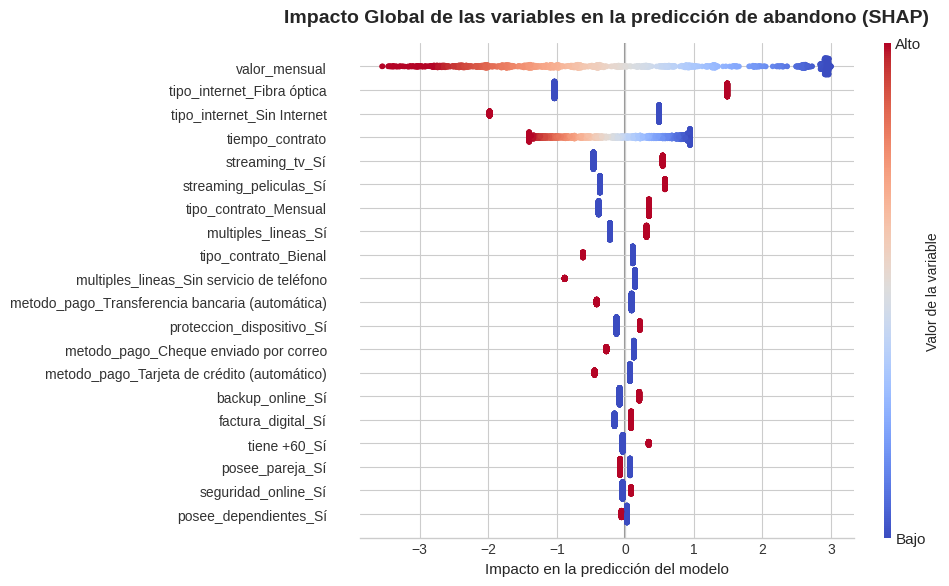

In [60]:
# Impacto Global de las variables en la predicción de abandono (SHAP)

# Crear explicador

explainer = shap.LinearExplainer(best_log, X_train_scaled)

# Calcular valores SHAP

shap_values = explainer.shap_values(X_test_scaled)

# Definor la configuración estética

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10,6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.size": 11
})

# Crear figura

plt.figure()

# Gráfico SHAP

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_train.columns,
    cmap="coolwarm",
    plot_size=(10,6),
    show=False
)

ax = plt.gca()

# Tamaño nombres de variables

ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

# Traducir barra de color

fig = plt.gcf()
cbar = fig.axes[-1]  # barra de color
cbar.set_ylabel("Valor de la variable", fontsize=10)
cbar.set_yticklabels(["Bajo", "Alto"])

# Título en español, negrita y tamaño 14

plt.title("Impacto Global de las variables en la predicción de abandono (SHAP)",
          fontsize=14, fontweight="bold", pad=15)

plt.xlabel("Impacto en la predicción del modelo", fontsize=11,)

plt.tight_layout()
plt.show()

>El análisis SHAP muestra cómo cada variable contribuye al aumento o reducción de la probabilidad de cancelación. Las ***variables con mayor impacto son valor_mensual, tipo de internet fibra óptica y tiempo_contrato.***

>***Valores altos de valor_mensual tienden a aumentar la probabilidad de churn, mientras que mayores tiempos de contrato se asocian con una menor probabilidad de abandono.*** Esto *confirma que tanto el costo del servicio como la permanencia del cliente son factores clave en la cancelación.*

In [61]:
# Función que permite crear un documento HTML completo listo para subir en vista interactiva

def exportar_grafico_html(fig, titulo, nombre_archivo, volver_link="index.html"):
    """
    Exporta un gráfico Plotly como archivo HTML con diseño personalizado.

    Parámetros:
    - fig: figura de Plotly
    - titulo: título que aparecerá en la pestaña del navegador
    - nombre_archivo: nombre del archivo (sin .html)
    - volver_link: enlace del botón de regreso (por defecto index.html)
    """

    plot_div = fig.to_html(include_plotlyjs='cdn', full_html=False)

    html_content = f"""
    <!DOCTYPE html>
    <html lang="es">
    <head>
        <meta charset="UTF-8">
        <title>{titulo}</title>

        <style>
            body {{
                font-family: Arial, sans-serif;
                background-color: #f4f6f9;
                margin: 0;
                padding: 40px;
            }}

            .btn {{
                position: fixed;
                top: 20px;
                left: 20px;
                padding: 10px 18px;
                background-color: #2563eb;
                color: white;
                text-decoration: none;
                border-radius: 8px;
                font-size: 14px;
                font-weight: 600;
                box-shadow: 0 4px 8px rgba(0,0,0,0.15);
                z-index: 9999;
            }}

            .btn:hover {{
                background-color: #1d4ed8;
            }}

            .container {{
                margin-top: 60px;
            }}
        </style>
    </head>

    <body>

    <a href="{volver_link}" class="btn">⬅ Volver al Dashboard</a>

    <div class="container">
    {plot_div}
    </div>

    </body>
    </html>
    """

    nombre_final = f"{nombre_archivo}.html"

    with open(nombre_final, "w", encoding="utf-8") as f:
        f.write(html_content)

    print(f"\n✅ Gráfico exportado como '{nombre_final}'\n")

In [62]:
# Generar graficos usando la función exportar_grafico_html

graficos = {
    "Matriz de Correlación: Variables Numéricas": fig_mcorr,
    "Correlación de Variables Numéricas con la Cancelación (Churn)": fig_corr,
    "Distribución de Variables Numéricas por Churn": fig_dist,
    "Optimización de Hiperparámetros: KNN": fig_knn,
    "Curva de Aprendizaje XGBoost: Entrenamiento vs Validación": fig_xgboost,
    "Curvas ROC por Modelo (Evaluación en Test)": fig_roc,
    "Curvas Precision-Recall por Modelo (Evaluación en Test)": fig_pr,
    "Comparativa de Matrices de Confusión": fig_mconfusion,
    "Consistencia de los Factores de Riesgo entre Modelos Líderes": fig_cfr,
    "Impacto de Variables en Churn (Odds Ratio - Regresión Logística)": fig_odds,
    "Importancia Simple de Variables (SHAP - Regresión Logística)": fig_isshap
}

for titulo, figura in graficos.items():
    exportar_grafico_html(figura, titulo, titulo)


✅ Gráfico exportado como 'Matriz de Correlación: Variables Numéricas.html'


✅ Gráfico exportado como 'Correlación de Variables Numéricas con la Cancelación (Churn).html'


✅ Gráfico exportado como 'Distribución de Variables Numéricas por Churn.html'


✅ Gráfico exportado como 'Optimización de Hiperparámetros: KNN.html'


✅ Gráfico exportado como 'Curva de Aprendizaje XGBoost: Entrenamiento vs Validación.html'


✅ Gráfico exportado como 'Curvas ROC por Modelo (Evaluación en Test).html'


✅ Gráfico exportado como 'Curvas Precision-Recall por Modelo (Evaluación en Test).html'


✅ Gráfico exportado como 'Comparativa de Matrices de Confusión.html'


✅ Gráfico exportado como 'Consistencia de los Factores de Riesgo entre Modelos Líderes.html'


✅ Gráfico exportado como 'Impacto de Variables en Churn (Odds Ratio - Regresión Logística).html'


✅ Gráfico exportado como 'Importancia Simple de Variables (SHAP - Regresión Logística).html'



---
## **5. Informe Final**
---

### *5.1 Objetivo del análisis*

>El propósito de este estudio fue desarrollar y comparar distintos modelos de machine learning para predecir la cancelación de clientes, identificar los factores más influyentes en el churn y proponer acciones de retención basadas en evidencia.
>
>Se trabajó con modelos de distinta naturaleza:
>
>- KNN (K-Nearest Neighbors)
>
>- SVM (Support Vector Machine)
>
>- Regresión Logística
>
>- Red Neuronal (MLP)
>
>- Árbol de Decisión
>
>- Random Forest
>
>- XGBoost (Gradient Boosting extremo)
>
>Además, se realizó análisis de correlación, selección de variables, evaluación comparativa de métricas, revisión de estabilidad y análisis interpretativo de variables mediante coeficientes, odds ratio, importancia de variables y SHAP.

### *5.2 Preparación de los datos y selección de variables*

>Antes del modelado se identificaron relaciones importantes entre variables:
>
>- ***valor_mensual y cuentas_diarias*** presentaban correlación perfecta, por lo que mantener ambas generaba redundancia. Se conservó valor_mensual por ser una métrica más interpretable.
>
>- ***tiempo_contrato y total_cobrado*** presentaban una correlación alta, lo que sugería solapamiento informativo. Se decidió conservar tiempo_contrato, ya que representa de forma más directa la permanencia del cliente.
>
>Esta depuración permitió reducir multicolinealidad y mejorar la interpretabilidad de los modelos, especialmente en Regresión Logística.

### *5.3 Hallazgos del análisis exploratorio*

>Los gráficos exploratorios mostraron patrones consistentes:
>
>- Los clientes que cancelan tienden a tener menor tiempo de contrato.
>
>- Los clientes que cancelan muestran menor total cobrado acumulado, lo que indica que muchas cancelaciones ocurren en etapas tempranas de la relación comercial.
>
>- Los clientes que cancelan presentan valores mensuales relativamente más altos, lo que sugiere sensibilidad al precio.
>
>- En la matriz de correlación, tiempo_contrato fue una de las variables con mayor relación negativa con churn, indicando que a mayor permanencia, menor cancelación.
>
>En conjunto, el análisis inicial ya sugería que el churn está estrechamente relacionado con:
>
>- permanencia del cliente,
>
>- precio del servicio,
>
>- tipo de contrato,
>
>- tipo de internet y servicios asociados.

### *5.4 Rendimiento comparativo de los modelos*

>Los modelos obtuvieron resultados relativamente cercanos, pero con diferencias importantes en su equilibrio entre precisión y recall.

>| Modelo                  | Accuracy   | Precisión  | >Recall     | F1-Score   |
>| ----------------------- | ---------- | ---------- | ---------- | ---------- |
>| **XGBoost**             | 76.40%     | 53.80%     | 79.41%     | **64.15%** |
>| **Regresión Logística** | 75.12%     | 52.13%     | 78.61%     | 62.69%     |
>| **Random Forest**       | 76.62%     | 54.53%     | 72.46%     | 62.23%     |
>| **Árbol de Decisión**   | 73.42%     | 50.00%     | **82.09%** | 62.15%     |
>| **SVM**                 | 74.06%     | 50.77%     | 79.14%     | 61.86%     |
>| **Red Neuronal (MLP)**  | **79.39%** | **62.14%** | 57.49%     | 59.72%     |
>| **KNN**                 | 76.83%     | 56.59%     | 55.08%     | 55.83%     |

>***Interpretación general***
>
>- XGBoost mostró el mejor desempeño global, al combinar el mayor F1-Score con una alta capacidad para detectar clientes que cancelan.
>
>- Regresión Logística obtuvo un rendimiento muy competitivo y, además, fue el modelo más interpretable.
>
>- Random Forest también mostró un desempeño sólido y estable.
>
>- Árbol de Decisión y SVM lograron recall alto, lo que significa que detectan muchos casos de churn, pero a costa de una menor precisión.
>
>- MLP logró el mayor accuracy, pero fue menos efectivo identificando churn.
>
>- KNN mostró el desempeño más bajo en términos de F1.

### *5.5 Evaluación con curvas ROC y Precision-Recall*

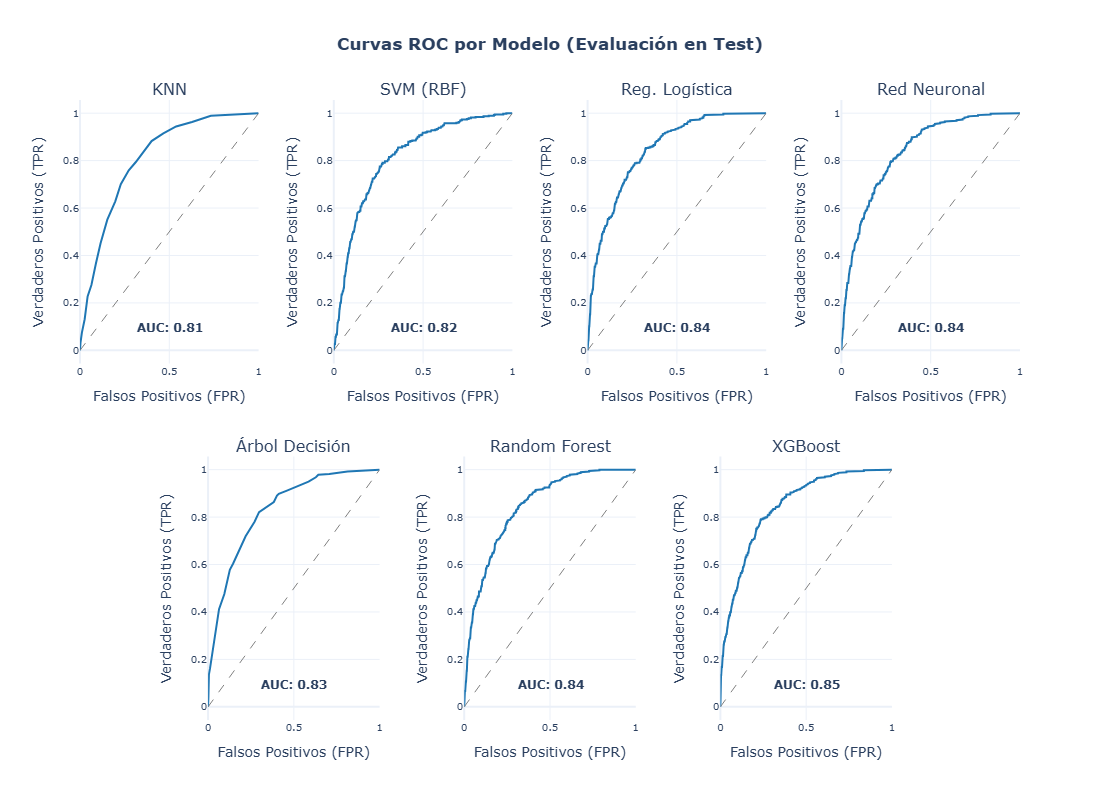

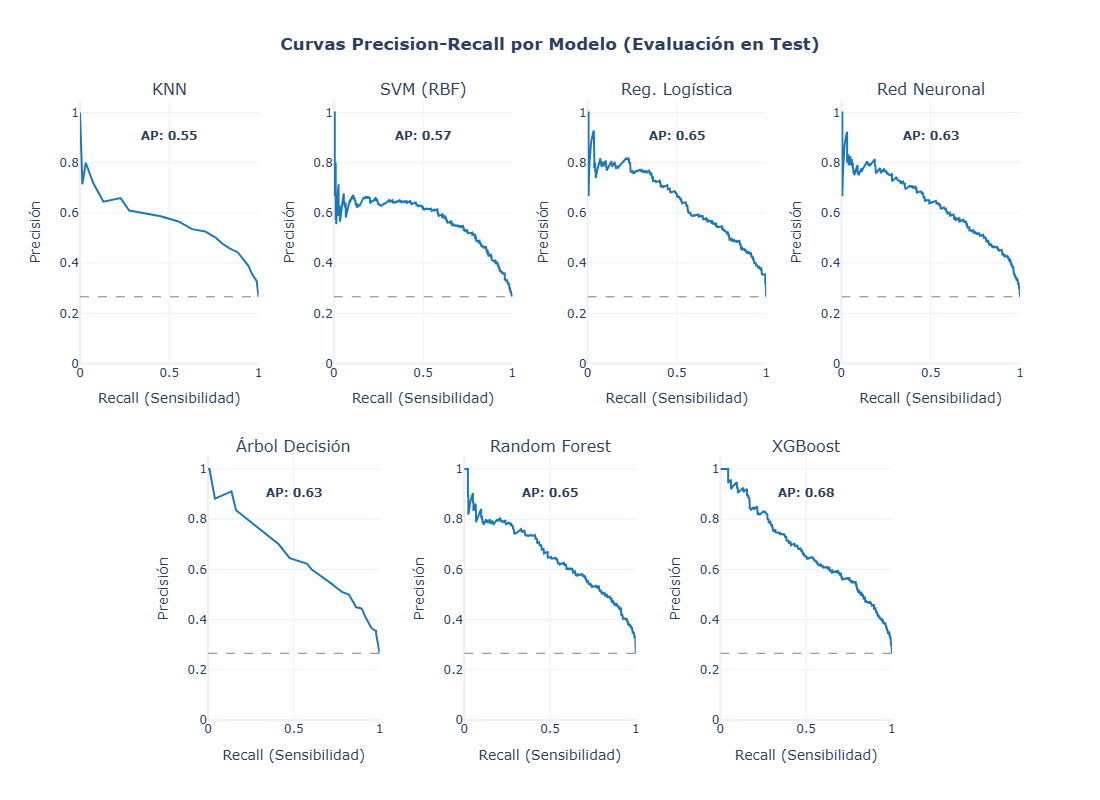

>Los gráficos complementarios reforzaron la comparación entre modelos:
>
>- XGBoost obtuvo el mejor comportamiento general en las curvas ROC y Precision-Recall.
>
>- Las curvas ROC mostraron que todos los modelos tienen una capacidad de discriminación razonable, pero XGBoost se mantuvo como el más robusto.
>
>- En problemas con desbalance moderado, como este, la curva Precision-Recall es especialmente relevante, y nuevamente XGBoost fue el modelo con mejor equilibrio entre detección y precisión.
>
>Esto confirma que, si el objetivo es construir un sistema predictivo de uso práctico, XGBoost es la mejor alternativa.

### *5.6 Estabilidad de los modelos*

>La validación cruzada mostró que los modelos con mejor desempeño también fueron consistentes:
>
>- ***Regresión Logística:*** F1 promedio 0.6331, estabilidad alta
>
>- ***Random Forest:*** F1 promedio 0.6306, estabilidad alta
>
>- ***XGBoost:*** F1 promedio 0.6279, estabilidad alta
>
>- ***SVM:*** F1 promedio 0.6225, estabilidad alta
>
>- ***Árbol de Decisión:*** F1 promedio 0.6143, estabilidad alta
>
>- ***MLP:*** F1 promedio 0.5886, estabilidad alta
>
>- ***KNN:*** F1 promedio 0.5816, estabilidad moderada
>
>Esto indica que los resultados no dependen excesivamente de una partición particular de los datos y que los modelos líderes son confiables.

### *5.7 Factores que más influyen en la cancelación*

>La interpretación de variables se apoyó en varios enfoques:
>
>- coeficientes y odds ratio de Regresión Logística,
>
>- importancia de variables en Random Forest y XGBoost,
>
>- análisis SHAP.
>
>Lo más importante es que los mismos factores aparecen repetidamente en distintos modelos, lo que fortalece la validez de los hallazgos.

#### *5.7.1 Factores que aumentan la cancelación*

>Los principales factores de riesgo identificados fueron:
>
>- ***tipo_internet_Fibra óptica***
>
>- ***tipo_contrato_Mensual***
>
>- ***streaming_tv_Sí***
>
>- ***streaming_peliculas_Sí***
>
>- ***valor_mensual***
>
>- ***servicios y características de planes más intensivos***
>
>Desde la Regresión Logística, por ejemplo:
>
>- ***tipo_internet_Fibra óptica*** mostró un odds ratio de aproximadamente ***3.5,*** siendo el factor individual más fuerte de aumento del churn.
>
>- ***streaming_tv_Sí y streaming_peliculas_Sí*** también aumentan la probabilidad de cancelación.
>
> ***tipo_contrato_Mensual*** incrementa el riesgo en comparación con contratos más largos.
>
>***Interpretación de negocio***
>
>Estos resultados sugieren que los clientes con:
>
>- planes más costosos,
>
>- contratos de corta duración,
>
>- internet de fibra,
>
>- y servicios de entretenimiento,
>
>son también clientes más expuestos a cancelar. Probablemente se trata de usuarios más exigentes, más sensibles al precio o con mayor facilidad para cambiar de proveedor.

#### *5.7.2 Factores que favorecen la retención*

>Los principales factores asociados a menor churn fueron:
>
>- ***tiempo_contrato***
>
>- ***tipo_contrato_Bienal***
>
>- ***tipo_internet_Sin Internet***
>
>- ***algunos métodos de pago automáticos***
>
>En particular:
>
>- ***tiempo_contrato*** fue uno de los factores más consistentes en todos los modelos. ***A mayor antigüedad del cliente, menor probabilidad de cancelación.***
>
>- ***tipo_contrato_Bienal actúa como factor de retención,*** reforzando la estabilidad de la relación con el cliente.
>
>- ***Los clientes con servicios más básicos también mostraron menor propensión a cancelar.***
>
>***Interpretación de negocio***
>
>Los clientes más antiguos y con contratos largos son más estables, lo que sugiere que la fidelización se fortalece con el tiempo. También indica que la flexibilidad del contrato mensual facilita la cancelación.

### *5.8 Integración de resultados entre modelos*

>***Uno de los hallazgos más importantes del proyecto es la consistencia de los factores de riesgo entre modelos líderes.***
>
>Tanto en:
>
>- Regresión Logística,
>
>- Random Forest,
>
>- XGBoost,
>
>- y SHAP,
>
>aparecen de forma recurrente variables como:
>
>- ***tiempo_contrato***
>
>- ***tipo_contrato_Mensual***
>
>- ***valor_mensual***
>
>- ***tipo_internet_Fibra óptica***
>
>Esto es metodológicamente muy valioso, porque indica que ***los factores detectados no son producto de un modelo aislado, sino patrones reales presentes en los datos.***

### *5.9 Perfil de cliente con mayor riesgo de cancelación*

>Con base en los resultados, ***el perfil de cliente con mayor probabilidad de churn corresponde a*** usuarios que presentan varias de estas características:
>
>- ***poca antigüedad en la empresa,***
>
>- ***contrato mensual,***
>
>- ***internet de fibra óptica,***
>
>- ***mayor valor mensual,***
>
>- ***presencia de servicios de streaming,***
>
>- ***menor consolidación de la relación con la empresa.***
>
>En contraste, el perfil más estable corresponde a clientes con:
>
>- mayor permanencia,
>
>- contratos de largo plazo,
>
>- servicios más básicos,
>
>- y menor propensión al cambio.

### *5.10 Estrategias de retención propuestas*

---
A partir de estos hallazgos, se proponen las siguientes acciones:

>***1. Incentivar contratos de mayor duración***
>
>Los contratos mensuales están fuertemente asociados al churn, mientras que los contratos bienales retienen mejor al cliente.
>
>***Estrategia:*** ofrecer descuentos, beneficios acumulativos o mejoras de servicio para migrar clientes mensuales a contratos anuales o bienales.
---
> ***2. Diseñar campañas tempranas de retención***
>
>El churn ocurre con mayor frecuencia en clientes con poca antigüedad.
>
>***Estrategia:*** activar campañas de onboarding, seguimiento y beneficios durante los primeros meses del cliente.
---
> ***3. Revisar la propuesta de valor de clientes con fibra óptica***
>
>La fibra óptica aparece como el principal factor de riesgo.
>
>***Estrategia:***  revisar calidad percibida, soporte técnico, estabilidad del servicio y estructura de precios en este segmento.
---
> ***4. Ajustar precios y percepción de costo***
>
>El valor mensual aparece como variable central en varios modelos.
>
>***Estrategia:*** evaluar paquetes más atractivos, descuentos segmentados o servicios de valor agregado para clientes con facturación alta.
---
> ***5. Intervenir segmentos con servicios de streaming***
>
>Los usuarios con TV y películas en streaming presentan mayor propensión al churn.
>
>***Estrategia:*** ofrecer bundles más competitivos, promociones cruzadas o beneficios exclusivos ligados a esos servicios.
---
> ***6. Implementar un sistema de alerta de riesgo***
>
>Dado que el modelo XGBoost mostró buen desempeño predictivo, puede emplearse como sistema de scoring de riesgo.
>
>***Estrategia:*** generar alertas automáticas para clientes con alta probabilidad de cancelación y priorizar sobre ellos campañas de retención.
---

### *5.11 Conclusión final*

>El análisis confirma que ***la cancelación*** de clientes ***está explicada*** principalmente ***por*** una combinación de factores asociados a la ***duración de la relación, el tipo de contrato, el precio del servicio y el tipo de plan contratado.***

>Entre los modelos evaluados, ***XGBoost presentó el mejor desempeño global,*** por lo que constituye la mejor opción para la predicción operativa del churn. No obstante, la ***Regresión Logística resultó especialmente valiosa para la interpretación,*** permitiendo comprender con claridad la dirección y magnitud ***del efecto de las variables.***

>Los hallazgos muestran que ***los clientes con contratos mensuales, internet de fibra óptica, servicios de streaming y menor antigüedad tienen mayor probabilidad de cancelar,*** mientras que ***la permanencia, los contratos largos y relaciones más consolidadas actúan como factores de retención.***

>En términos de negocio, esto sugiere que una estrategia efectiva de reducción del churn debe enfocarse en:
>
>- fortalecer la retención temprana,
>
>- incentivar contratos de mayor duración,
>
>- revisar la experiencia de clientes con fibra óptica,
>
> - y optimizar la propuesta de valor para clientes de mayor costo mensual.